In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, hamming_loss, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
df=pd.read_csv("/kaggle/input/cdataset/Multilablel Cyberbully Data.csv")
df.sample(10)

,Gender,Profession,comment,bully,sexual,religious,threat,spam
2214,male,doctor,কমেন্ট করা জনগণ গুলো কই সবাই হাত তুলো আমি লিষ্...,1,0,0,0,0
2249,male,doctor,আহ,0,0,0,0,0
546,male,social,ওরে হাতির বাচ্চা রে তোমার জন্য সালিনিয়ন রে লাগবে,1,1,0,0,0
4151,female,actor,আপনার দাতের যে বিউ তালে ফর ইউ,0,0,0,0,0
732,female,social,প্লিজ আপু অনুরোধ রইল আমার একটা ভিডিও লাইক কমেন...,0,0,0,0,1
11061,female,actor,জুতার বাড়ি কুত্তা তোর মুখে,1,0,0,1,0
871,female,dancer,আপুরা অনলাইনে জব করতে চাইলে ফলো দিয়া ইনবক্স করো,0,0,0,0,1
8082,female,social,টেটু করা ভলো না,0,0,0,0,0
6578,female,dancer,নাইস,0,0,0,0,0
1448,male,sports,ওহ অনেক সুন্দর,0,0,0,0,0


In [3]:
#check the rows and columns number.
print(f"number of rows:--> {df.shape[0]} and number of columns:--> {df.shape[1]}")

number of rows:--> 12546 and number of columns:--> 8


In [4]:
#check for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12546 entries, 0 to 12545
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Gender      12546 non-null  object
 1   Profession  12546 non-null  object
 2   comment     12546 non-null  object
 3   bully       12546 non-null  int64 
 4   sexual      12546 non-null  int64 
 5   religious   12546 non-null  int64 
 6   threat      12546 non-null  int64 
 7   spam        12546 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 784.3+ KB


In [5]:
#check for missing values 
def checking_m(df):
    null_v = df.isnull().sum().sort_values(ascending=False)
    null_percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
    null_v = pd.concat([null_v, null_percent], axis=1, keys=['Missing_Number', 'Missing_Percent'])
    return null_v

checking_m(df)

,Missing_Number,Missing_Percent
Gender,0,0.0
Profession,0,0.0
comment,0,0.0
bully,0,0.0
sexual,0,0.0
religious,0,0.0
threat,0,0.0
spam,0,0.0


In [6]:
#check for dublicated rows
print("Numbers of duplicated rows :",df.duplicated().sum())

Numbers of duplicated rows : 1291


In [7]:
#counting text length
df['count'] = df['comment'].str.split().str.len()

# Remove the text with words less than 3
df= df.loc[df['count']>2]


In [8]:
df.shape

(10188, 9)

In [9]:
import re

def clean_bangla_text(text):
    # Remove English letters and digits only
    text = re.sub(r'[A-Za-z0-9]', '', text)

    # Remove unwanted punctuation (but keep । ! ? , )
    text = re.sub(r'[“”"\'’‘`^~–—…•°•→←<>/\\|_=+()*&^%$#@{}[\]<>]', ' ', text)

    # Remove newlines and tabs
    text = text.replace("\n", " ").replace("\t", " ")

    # Normalize multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['comment'] = df['comment'].apply(clean_bangla_text)

In [10]:
df.sample(10)

,Gender,Profession,comment,bully,sexual,religious,threat,spam,count
6282,female,social,এটু সাপোর্ট করবেন ইনশাআল্লহা আমিও করবো,0,0,1,0,1,6
2697,female,social,আরেক টু নিছে লাগান মজা পাবেন,1,1,0,0,0,6
5909,male,social,এরপর বাংলা ছবির কোনোদিন নাম ও দেখবো না,0,0,0,0,0,8
9518,female,actor,সাপোর্ট দেওয়ার জন্য ধন্যবাদ ভাইয়া,0,0,0,0,1,5
5624,female,social,দূর তো পাচা নাই,1,1,0,0,0,4
6887,female,social,সব হাতের খেলা,1,0,0,0,0,3
5994,female,social,আচ্ছা ভারতে মুসলমানরা যতই নির্যাতিত হোক তারা ত...,0,0,1,0,0,38
3125,male,sports,ভাই আমিও এখানে যাওয়ার সুযোগ হইছে সেই সুন্দর জাইগা,0,0,0,0,0,9
4102,female,actor,মোটা হয়ে গেছে,1,0,0,0,0,3
6205,female,social,ভাই এর নাম কি,0,0,0,0,0,4


In [11]:
# Length of each cleaned comment (in tokens/words, split by space)
df['token_len'] = df['comment'].apply(lambda x: len(x.split()))

# Maximum token length
max_token_len = df['token_len'].max()

print("Maximum token length:", max_token_len)
df[['comment', 'token_len']].head()


Maximum token length: 178


,comment,token_len
0,এই দেশে এইসব কি হচ্ছে,5
1,মানে কি বলব,3
2,ভাই ভিডিও ফুল প্লিজ,4
3,নিজের খরচ নিজেই চালাতে পারবেন এমন ভালো একটা জব...,14
4,ভিডিও কলে রেগুলার কাজ করতে পারবেন,6


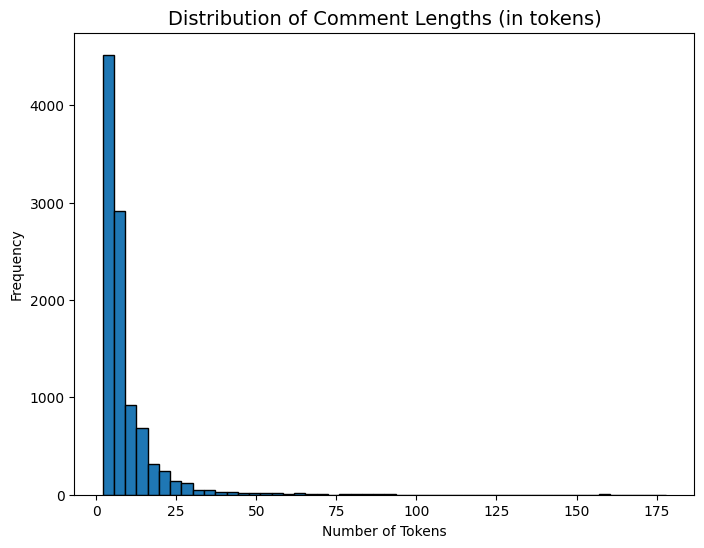

In [12]:
import matplotlib.pyplot as plt

# Distribution of token lengths (assuming you already added df['token_len'])
plt.figure(figsize=(8,6))
plt.hist(df['token_len'], bins=50, edgecolor='black')
plt.title("Distribution of Comment Lengths (in tokens)", fontsize=14)
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()


In [13]:
# Define label columns
label_cols = ['bully', 'sexual', 'religious', 'threat', 'spam']

# Prepare features and labels
texts = df['comment'].values
labels = df[label_cols].values.astype(np.float32)

labels

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 1.],
       ...,
       [1., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 1., 0., 0.]], dtype=float32)

In [14]:
print(f"Dataset size: {len(texts)}")
print(f"Label distribution:\n{df[label_cols].sum()}")


Dataset size: 10188
Label distribution:
bully        6882
sexual       1802
religious    1445
threat       1403
spam          933
dtype: int64


In [15]:
# Train-validation-test split (80-10-10)
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels.sum(axis=1)
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp.sum(axis=1)
)

print(f"\nTrain: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 8150, Val: 1019, Test: 1019


# ======================== LSTM ========================

In [16]:
# ========================
# 3. MODEL ARCHITECTURE: LSTM Only
# ========================

class LSTMOnly(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=256, num_layers=2, 
                 num_labels=5, dropout=0.3, padding_idx=0):
        super(LSTMOnly, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)
        
    def forward(self, input_ids, attention_mask=None):
        # input_ids shape: (batch_size, seq_length)
        embeddings = self.embedding(input_ids)  # (batch_size, seq_length, embedding_dim)
        
        lstm_output, (hidden, cell) = self.lstm(embeddings)
        # Concatenate last hidden states from both directions
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        hidden = self.dropout(hidden)
        logits = self.classifier(hidden)
        return logits


In [25]:
# ========================
# 4. DATA PREPARATION FOR LSTM
# ========================

# We need to create a vocabulary and update the dataset class
class LSTMDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, vocab, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.vocab = vocab
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Simple tokenization (split by space)
        tokens = text.split()[:self.max_len]
        
        # Convert tokens to indices
        input_ids = [self.vocab.get(token, self.vocab['<UNK>']) for token in tokens]
        
        # Padding
        if len(input_ids) < self.max_len:
            input_ids = input_ids + [self.vocab['<PAD>']] * (self.max_len - len(input_ids))
        else:
            input_ids = input_ids[:self.max_len]
        
        attention_mask = [1 if token != self.vocab['<PAD>'] else 0 for token in input_ids]
        
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.float)
        }

In [26]:
# Build vocabulary
def build_vocab(texts, min_freq=2):
    vocab = {'<PAD>': 0, '<UNK>': 1}
    word_freq = {}
    
    # Count word frequencies
    for text in texts:
        tokens = str(text).split()
        for token in tokens:
            word_freq[token] = word_freq.get(token, 0) + 1
    
    # Add words to vocabulary based on frequency
    idx = 2
    for word, freq in word_freq.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    
    return vocab

In [27]:
# ========================
# 5. MAIN TRAINING PIPELINE - LSTMOnly
# ========================

# Configuration
MAX_LEN = 64
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-3
EMBEDDING_DIM = 300
HIDDEN_DIM = 256
LSTM_LAYERS = 2

# Build vocabulary from training data
print("Building vocabulary...")
vocab = build_vocab(X_train)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# Create datasets
train_dataset = LSTMDataset(X_train, y_train, None, vocab, MAX_LEN)
val_dataset = LSTMDataset(X_val, y_val, None, vocab, MAX_LEN)
test_dataset = LSTMDataset(X_test, y_test, None, vocab, MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Initialize LSTM-only model
model = LSTMOnly(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=LSTM_LAYERS,
    num_labels=len(label_cols)
).to(device)

print(f"\nModel: LSTMOnly")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Building vocabulary...
Vocabulary size: 5236

Model: LSTMOnly
Total parameters: 4,293,109


In [28]:
def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc='Training')
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        logits = model(input_ids, attention_mask)
        loss = nn.BCEWithLogitsLoss()(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        
        # Calculate accuracy
        preds = torch.sigmoid(logits) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy

def eval_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    progress_bar = tqdm(dataloader, desc='Validation')
    
    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            logits = model(input_ids, attention_mask)
            loss = nn.BCEWithLogitsLoss()(logits, labels)
            
            total_loss += loss.item()
            
            probs = torch.sigmoid(logits)
            preds = probs > 0.5
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)


In [29]:
# Optimizer (different learning rate for LSTM)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

In [30]:
# ========================
# 6. TRAINING LOOP - LSTMOnly
# ========================

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n" + "="*50)
print("STARTING TRAINING - LSTMOnly")
print("="*50)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    
    # Validate
    val_loss, val_acc, _, _, _ = eval_epoch(model, val_loader, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save last model checkpoint (not best)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'vocab': vocab,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc
    }, 'last_model_checkpoint_lstm_only.pt')
    print(f"✓ Last LSTMOnly model checkpoint saved! (Epoch {epoch+1})")

print("\n" + "="*50)
print("TRAINING COMPLETED - LSTMOnly")
print("="*50)

# Print final training and validation metrics
print(f"\nFINAL TRAINING METRICS - LSTMOnly:")
print(f"Last Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Last Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Last Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Last Validation Accuracy: {history['val_acc'][-1]:.4f}")


STARTING TRAINING - LSTMOnly

Epoch 1/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.4093 | Train Acc: 0.8433
Val Loss: 0.2711 | Val Acc: 0.8964
✓ Last LSTMOnly model checkpoint saved! (Epoch 1)

Epoch 2/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0281 | Train Acc: 0.9894
Val Loss: 0.3513 | Val Acc: 0.9123
✓ Last LSTMOnly model checkpoint saved! (Epoch 9)

Epoch 10/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0233 | Train Acc: 0.9906
Val Loss: 0.3669 | Val Acc: 0.9123
✓ Last LSTMOnly model checkpoint saved! (Epoch 10)

TRAINING COMPLETED - LSTMOnly

FINAL TRAINING METRICS - LSTMOnly:
Last Train Loss: 0.0233
Last Train Accuracy: 0.9906
Last Validation Loss: 0.3669
Last Validation Accuracy: 0.9123


In [31]:
# ========================
# 7. TEST EVALUATION - LSTMOnly
# ========================

print("\n" + "="*50)
print("TESTING WITH LAST LSTMOnly MODEL")
print("="*50)

# # Load last model checkpoint
# checkpoint = torch.load('last_model_checkpoint_lstm_only.pt')
# model.load_state_dict(checkpoint['model_state_dict'])

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels, test_probs = eval_epoch(model, test_loader, device)

print(f"\n{'='*50}")
print(f"TEST RESULTS - LSTMOnly")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Hamming Loss: {hamming_loss(test_labels, test_preds):.4f}")


TESTING WITH LAST LSTMOnly MODEL


Validation:   0%|          | 0/32 [00:00<?, ?it/s]


TEST RESULTS - LSTMOnly
Test Loss: 0.3648
Test Accuracy: 0.9152
Hamming Loss: 0.0848


In [32]:
# Calculate precision, recall, F1 scores
precision = precision_score(test_labels, test_preds, average='micro', zero_division=0)
recall = recall_score(test_labels, test_preds, average='micro', zero_division=0)
f1 = f1_score(test_labels, test_preds, average='micro', zero_division=0)

print(f"\nOverall Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")



Overall Metrics:
Precision: 0.8308
Recall: 0.8201
F1-Score: 0.8254


In [33]:

# ========================
# MCC AND COHEN'S KAPPA SCORES
# ========================

from sklearn.metrics import matthews_corrcoef, cohen_kappa_score
import numpy as np

# Convert to numpy arrays
test_labels_np = np.array(test_labels)
test_preds_np = np.array(test_preds)

class_names = ['bully', 'sexual', 'religious', 'threat', 'spam']

print(f"\n{'='*50}")
print(f"MCC AND COHEN'S KAPPA SCORES")
print(f"{'='*50}")

# Calculate for each class
mcc_scores = []
kappa_scores = []

print("\nPer-class Scores:")
for i, class_name in enumerate(class_names):
    mcc = matthews_corrcoef(test_labels_np[:, i], test_preds_np[:, i])
    kappa = cohen_kappa_score(test_labels_np[:, i], test_preds_np[:, i])
    
    mcc_scores.append(mcc)
    kappa_scores.append(kappa)
    
    print(f"{class_name:>10}: MCC = {mcc:.4f}, Cohen's Kappa = {kappa:.4f}")

# Calculate averages
average_mcc = np.mean(mcc_scores)
average_kappa = np.mean(kappa_scores)

print(f"\nAverage Scores:")
print(f"MCC: {average_mcc:.4f}")
print(f"Cohen's Kappa: {average_kappa:.4f}")


MCC AND COHEN'S KAPPA SCORES

Per-class Scores:
     bully: MCC = 0.6645, Cohen's Kappa = 0.6631
    sexual: MCC = 0.4927, Cohen's Kappa = 0.4912
 religious: MCC = 0.7893, Cohen's Kappa = 0.7880
    threat: MCC = 0.7229, Cohen's Kappa = 0.7227
      spam: MCC = 0.7888, Cohen's Kappa = 0.7886

Average Scores:
MCC: 0.6916
Cohen's Kappa: 0.6907


In [34]:
# Per-label metrics
print(f"\n{'='*50}")
print("PER-LABEL CLASSIFICATION REPORT - LSTMOnly")
print(f"{'='*50}")
print(classification_report(
    test_labels, 
    test_preds, 
    target_names=label_cols,
    zero_division=0
))


PER-LABEL CLASSIFICATION REPORT - LSTMOnly
              precision    recall  f1-score   support

       bully       0.88      0.91      0.90       693
      sexual       0.60      0.53      0.56       155
   religious       0.86      0.78      0.82       143
      threat       0.78      0.75      0.77       164
        spam       0.83      0.79      0.81        90

   micro avg       0.83      0.82      0.83      1245
   macro avg       0.79      0.75      0.77      1245
weighted avg       0.83      0.82      0.82      1245
 samples avg       0.70      0.68      0.67      1245



In [35]:
# Calculate AUC-ROC for each class
print(f"\n{'='*50}")
print("AUC-ROC SCORES FOR EACH CLASS - LSTMOnly")
print(f"{'='*50}")
for i, label in enumerate(label_cols):
    try:
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        print(f"{label}: {auc:.4f}")
    except ValueError:
        print(f"{label}: Could not calculate AUC (only one class present)")

# Calculate overall micro and macro AUC
try:
    micro_auc = roc_auc_score(test_labels, test_probs, average='micro')
    macro_auc = roc_auc_score(test_labels, test_probs, average='macro')
    print(f"\nMicro AUC: {micro_auc:.4f}")
    print(f"Macro AUC: {macro_auc:.4f}")
except ValueError:
    print("\nCould not calculate overall AUC scores")


AUC-ROC SCORES FOR EACH CLASS - LSTMOnly
bully: 0.8919
sexual: 0.8578
religious: 0.9308
threat: 0.9303
spam: 0.9464

Micro AUC: 0.9476
Macro AUC: 0.9114


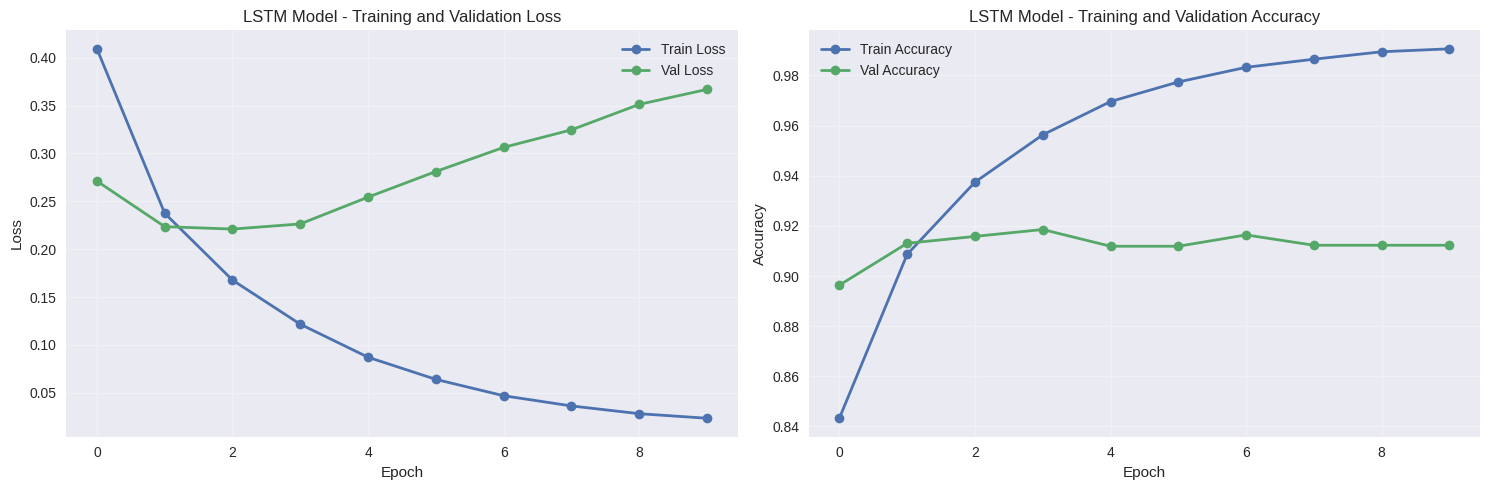

In [36]:
# ========================
# 9. PLOT TRAINING HISTORY - LSTMOnly
# ========================

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('LSTM Model - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('LSTM Model - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('LSTMOnly_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

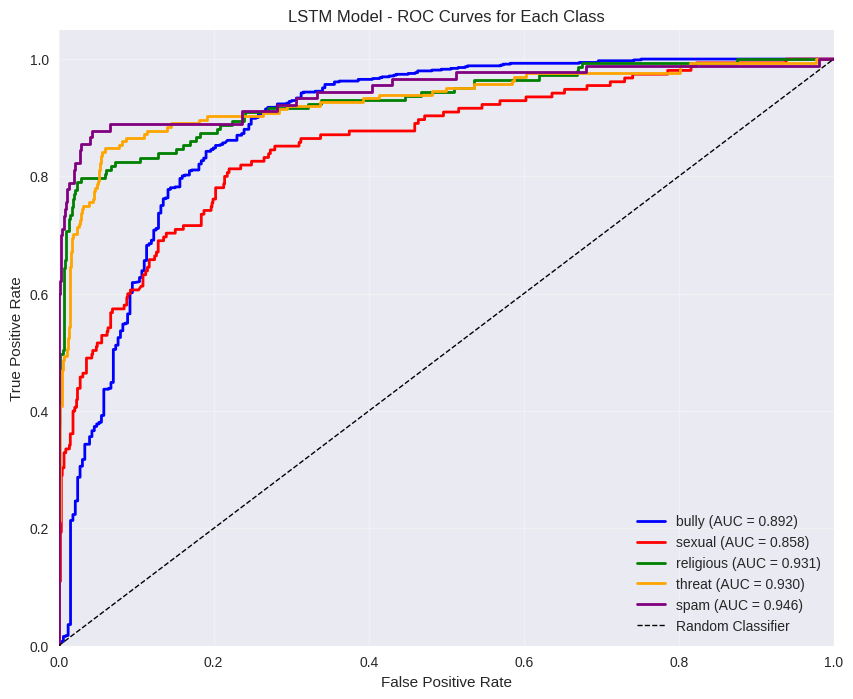

In [37]:
# ========================
# 10. PLOT ROC CURVES - LSTMOnly
# ========================

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, label in enumerate(label_cols):
    try:
        fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        plt.plot(fpr, tpr, color=colors[i], linewidth=2, 
                label=f'{label} (AUC = {auc:.3f})')
    except ValueError:
        continue

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LSTM Model - ROC Curves for Each Class')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('LSTMOnly_ROC_curves.png', dpi=300, bbox_inches='tight')
plt.show()


COMPREHENSIVE CONFUSION MATRIX


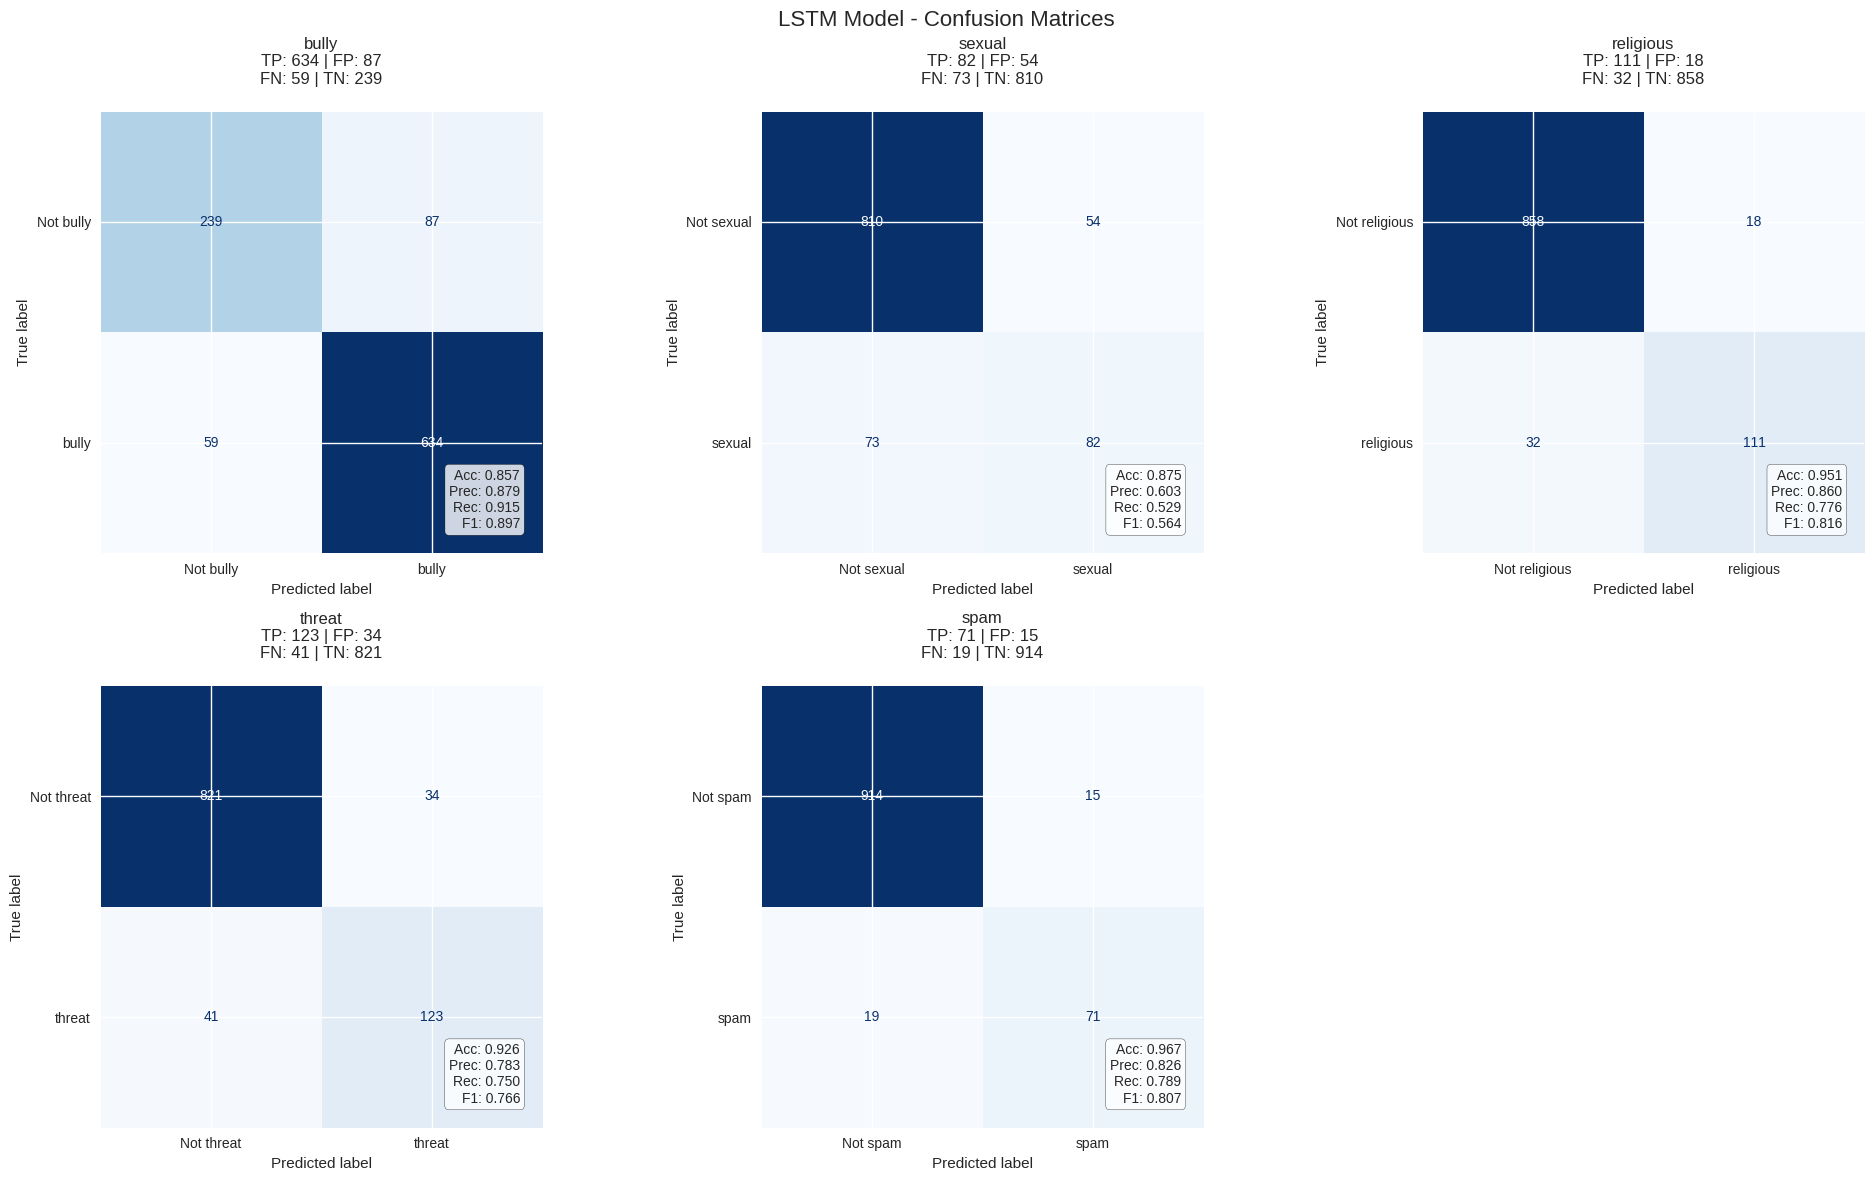

In [38]:
# Add this import at the top
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay

# ========================
# CONFUSION MATRIX SECTION 
# ========================

print(f"\n{'='*50}")
print("COMPREHENSIVE CONFUSION MATRIX")
print(f"{'='*50}")

# Create multilabel confusion matrix
mcm = multilabel_confusion_matrix(test_labels, test_preds)

# Plot a single comprehensive figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, (label, cm) in enumerate(zip(label_cols, mcm)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not '+label, label])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f'{label}\nTP: {cm[1,1]} | FP: {cm[0,1]}\nFN: {cm[1,0]} | TN: {cm[0,0]}', 
                     fontsize=12, pad=20)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # Add metrics as text
    metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
    axes[i].text(0.95, 0.05, metrics_text, transform=axes[i].transAxes, 
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10)

# Hide the last subplot if we have odd number of labels
if len(label_cols) < len(axes):
    for i in range(len(label_cols), len(axes)):
        axes[i].set_visible(False)

plt.suptitle('LSTM Model - Confusion Matrices', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()



In [39]:
# ========================
# 11. SAMPLE PREDICTIONS - LSTMOnly
# ========================

def predict_cyberbullying_lstm(text, model, vocab, device, threshold=0.5):
    """Predict cyberbullying categories for a single text using LSTM model"""
    model.eval()
    
    # Tokenize and convert to indices
    tokens = text.split()[:MAX_LEN]
    input_ids = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    
    # Padding
    if len(input_ids) < MAX_LEN:
        input_ids = input_ids + [vocab['<PAD>']] * (MAX_LEN - len(input_ids))
    else:
        input_ids = input_ids[:MAX_LEN]
    
    input_ids = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(input_ids)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        preds = (probs > threshold).astype(int)
    
    results = {label: {'prediction': int(pred), 'probability': float(prob)} 
               for label, pred, prob in zip(label_cols, preds, probs)}
    
    return results

# Display 3 sample predictions from test data
print(f"\n{'='*50}")
print("SAMPLE PREDICTIONS FROM TEST DATA - LSTM")
print(f"{'='*50}")

# Get 3 random samples from test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 3, replace=False)

for i, idx in enumerate(sample_indices, 1):
    sample_text = X_test[idx]
    true_labels = y_test[idx]
    
    print(f"\nSample {i}:")
    print(f"Text: {sample_text}")
    
    # Get predictions
    predictions = predict_cyberbullying_lstm(sample_text, model, vocab, device)
    
    print("Predictions:")
    for label in label_cols:
        pred = predictions[label]['prediction']
        prob = predictions[label]['probability']
        true = int(true_labels[label_cols.index(label)])
        
        status = "✓" if pred == true else "✗"
        print(f"  {label}: Pred={pred} (prob: {prob:.3f}), True={true}")


SAMPLE PREDICTIONS FROM TEST DATA - LSTM

Sample 1:
Text: চলচ্চিত্র জগতে জাহিদের কি অবদান আরেকজনকে কিভাবে অপমান করে তাকে জুতাপেটা করা দরকার
Predictions:
  bully: Pred=1 (prob: 1.000), True=1
  sexual: Pred=0 (prob: 0.012), True=0
  religious: Pred=0 (prob: 0.001), True=0
  threat: Pred=1 (prob: 0.999), True=1
  spam: Pred=0 (prob: 0.000), True=0

Sample 2:
Text: সবার সাপোর্ট চাই ভাই আইডিটা ফিরিয়ে গেছেএকটু সাপোর্ট কইরা দিয়েন
Predictions:
  bully: Pred=0 (prob: 0.000), True=0
  sexual: Pred=0 (prob: 0.000), True=0
  religious: Pred=0 (prob: 0.347), True=0
  threat: Pred=0 (prob: 0.001), True=0
  spam: Pred=1 (prob: 0.999), True=1

Sample 3:
Text: দুধটা খুইলা একটু ভালো করে করলা একটু মজা লাগবে
Predictions:
  bully: Pred=1 (prob: 0.999), True=1
  sexual: Pred=1 (prob: 0.564), True=1
  religious: Pred=0 (prob: 0.000), True=0
  threat: Pred=0 (prob: 0.001), True=0
  spam: Pred=0 (prob: 0.001), True=0


# ===================== END ======================

# Bi-LSTM

In [40]:

class BiLSTMOnly(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=256, num_layers=2, 
                 num_labels=5, dropout=0.3, padding_idx=0):
        super(BiLSTMOnly, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)
        
    def forward(self, input_ids, attention_mask=None):
        # input_ids shape: (batch_size, seq_length)
        embeddings = self.embedding(input_ids)  # (batch_size, seq_length, embedding_dim)
        
        lstm_output, (hidden, cell) = self.lstm(embeddings)
        # Concatenate last hidden states from both directions
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        hidden = self.dropout(hidden)
        logits = self.classifier(hidden)
        return logits

In [41]:
class LSTMDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=64):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab  # This should be a dictionary
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Simple tokenization (split by space)
        tokens = text.split()[:self.max_len]
        
        # Convert tokens to indices - FIXED: directly access vocab dictionary
        input_ids = []
        for token in tokens:
            if token in self.vocab:
                input_ids.append(self.vocab[token])
            else:
                input_ids.append(self.vocab['<UNK>'])
        
        # Padding
        if len(input_ids) < self.max_len:
            input_ids = input_ids + [self.vocab['<PAD>']] * (self.max_len - len(input_ids))
        else:
            input_ids = input_ids[:self.max_len]
        
        attention_mask = [1 if token != self.vocab['<PAD>'] else 0 for token in input_ids]
        
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.float)
        }

In [42]:
def build_vocab(texts, min_freq=2):
    vocab = {'<PAD>': 0, '<UNK>': 1}
    word_freq = {}
    
    # Count word frequencies
    for text in texts:
        tokens = str(text).split()
        for token in tokens:
            word_freq[token] = word_freq.get(token, 0) + 1
    
    # Add words to vocabulary based on frequency
    idx = 2
    for word, freq in word_freq.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    
    return vocab

In [43]:
# Build vocabulary
print("Building vocabulary...")
vocab = build_vocab(X_train)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

Building vocabulary...
Vocabulary size: 5236


In [44]:
# Create datasets
train_dataset = LSTMDataset(X_train, y_train, vocab, MAX_LEN)
val_dataset = LSTMDataset(X_val, y_val, vocab, MAX_LEN)
test_dataset = LSTMDataset(X_test, y_test, vocab, MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Initialize BiLSTM-only model
model = BiLSTMOnly(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=LSTM_LAYERS,
    num_labels=len(label_cols)
).to(device)

print(f"\nModel: BiLSTMOnly")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")



Model: BiLSTMOnly
Total parameters: 4,293,109


In [45]:
# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)


In [46]:
def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc='Training')
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        logits = model(input_ids, attention_mask)
        loss = nn.BCEWithLogitsLoss()(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        
        # Calculate accuracy
        preds = torch.sigmoid(logits) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy

def eval_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    progress_bar = tqdm(dataloader, desc='Validation')
    
    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            logits = model(input_ids, attention_mask)
            loss = nn.BCEWithLogitsLoss()(logits, labels)
            
            total_loss += loss.item()
            
            probs = torch.sigmoid(logits)
            preds = probs > 0.5
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)


In [47]:
# ========================
# 3. TRAINING LOOP - BiLSTMOnly
# ========================

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n" + "="*50)
print("STARTING TRAINING - BiLSTMOnly")
print("="*50)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    
    # Validate
    val_loss, val_acc, _, _, _ = eval_epoch(model, val_loader, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save last model checkpoint (not best)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'vocab': vocab,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc
    }, 'last_model_checkpoint_bilstm_only.pt')
    print(f"✓ Last BiLSTMOnly model checkpoint saved! (Epoch {epoch+1})")

print("\n" + "="*50)
print("TRAINING COMPLETED - BiLSTMOnly")
print("="*50)

# Print final training and validation metrics
print(f"\nFINAL TRAINING METRICS - BiLSTM:")
print(f"Last Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Last Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Last Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Last Validation Accuracy: {history['val_acc'][-1]:.4f}")


STARTING TRAINING - BiLSTMOnly

Epoch 1/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.4134 | Train Acc: 0.8208
Val Loss: 0.2722 | Val Acc: 0.8934
✓ Last BiLSTMOnly model checkpoint saved! (Epoch 1)

Epoch 2/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0271 | Train Acc: 0.9892
Val Loss: 0.3435 | Val Acc: 0.9158
✓ Last BiLSTMOnly model checkpoint saved! (Epoch 9)

Epoch 10/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0226 | Train Acc: 0.9909
Val Loss: 0.3617 | Val Acc: 0.9150
✓ Last BiLSTMOnly model checkpoint saved! (Epoch 10)

TRAINING COMPLETED - BiLSTMOnly

FINAL TRAINING METRICS - BiLSTM:
Last Train Loss: 0.0226
Last Train Accuracy: 0.9909
Last Validation Loss: 0.3617
Last Validation Accuracy: 0.9150


In [48]:
# ========================
# 7. TEST EVALUATION - BiLSTMOnly
# ========================

print("\n" + "="*50)
print("TESTING WITH LAST BiLSTM MODEL")
print("="*50)

# # Load last model checkpoint
# checkpoint = torch.load('last_model_checkpoint_bilstm_only.pt')
# model.load_state_dict(checkpoint['model_state_dict'])

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels, test_probs = eval_epoch(model, test_loader, device)

print(f"\n{'='*50}")
print(f"TEST RESULTS - BiLSTM")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Hamming Loss: {hamming_loss(test_labels, test_preds):.4f}")


TESTING WITH LAST BiLSTM MODEL


Validation:   0%|          | 0/32 [00:00<?, ?it/s]


TEST RESULTS - BiLSTM
Test Loss: 0.3698
Test Accuracy: 0.9134
Hamming Loss: 0.0866


In [49]:
# Calculate precision, recall, F1 scores
precision = precision_score(test_labels, test_preds, average='micro', zero_division=0)
recall = recall_score(test_labels, test_preds, average='micro', zero_division=0)
f1 = f1_score(test_labels, test_preds, average='micro', zero_division=0)

print(f"\nOverall Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Overall Metrics:
Precision: 0.8317
Recall: 0.8096
F1-Score: 0.8205


In [50]:
# Per-label metrics
print(f"\n{'='*50}")
print("PER-LABEL CLASSIFICATION REPORT - BiLSTMOnly")
print(f"{'='*50}")
print(classification_report(
    test_labels, 
    test_preds, 
    target_names=label_cols,
    zero_division=0
))



PER-LABEL CLASSIFICATION REPORT - BiLSTMOnly
              precision    recall  f1-score   support

       bully       0.87      0.90      0.89       693
      sexual       0.60      0.55      0.57       155
   religious       0.85      0.76      0.80       143
      threat       0.86      0.72      0.78       164
        spam       0.81      0.81      0.81        90

   micro avg       0.83      0.81      0.82      1245
   macro avg       0.80      0.75      0.77      1245
weighted avg       0.83      0.81      0.82      1245
 samples avg       0.69      0.67      0.67      1245



In [51]:

# ========================
# MCC AND COHEN'S KAPPA SCORES
# ========================

from sklearn.metrics import matthews_corrcoef, cohen_kappa_score
import numpy as np

# Convert to numpy arrays
test_labels_np = np.array(test_labels)
test_preds_np = np.array(test_preds)

class_names = ['bully', 'sexual', 'religious', 'threat', 'spam']

print(f"\n{'='*50}")
print(f"MCC AND COHEN'S KAPPA SCORES")
print(f"{'='*50}")

# Calculate for each class
mcc_scores = []
kappa_scores = []

print("\nPer-class Scores:")
for i, class_name in enumerate(class_names):
    mcc = matthews_corrcoef(test_labels_np[:, i], test_preds_np[:, i])
    kappa = cohen_kappa_score(test_labels_np[:, i], test_preds_np[:, i])
    
    mcc_scores.append(mcc)
    kappa_scores.append(kappa)
    
    print(f"{class_name:>10}: MCC = {mcc:.4f}, Cohen's Kappa = {kappa:.4f}")

# Calculate averages
average_mcc = np.mean(mcc_scores)
average_kappa = np.mean(kappa_scores)

print(f"\nAverage Scores:")
print(f"MCC: {average_mcc:.4f}")
print(f"Cohen's Kappa: {average_kappa:.4f}")


MCC AND COHEN'S KAPPA SCORES

Per-class Scores:
     bully: MCC = 0.6309, Cohen's Kappa = 0.6300
    sexual: MCC = 0.5030, Cohen's Kappa = 0.5022
 religious: MCC = 0.7714, Cohen's Kappa = 0.7696
    threat: MCC = 0.7476, Cohen's Kappa = 0.7438
      spam: MCC = 0.7928, Cohen's Kappa = 0.7928

Average Scores:
MCC: 0.6891
Cohen's Kappa: 0.6877


In [52]:
# Calculate AUC-ROC for each class
print(f"\n{'='*50}")
print("AUC-ROC SCORES FOR EACH CLASS - BiLSTM")
print(f"{'='*50}")
for i, label in enumerate(label_cols):
    try:
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        print(f"{label}: {auc:.4f}")
    except ValueError:
        print(f"{label}: Could not calculate AUC (only one class present)")

# Calculate overall micro and macro AUC
try:
    micro_auc = roc_auc_score(test_labels, test_probs, average='micro')
    macro_auc = roc_auc_score(test_labels, test_probs, average='macro')
    print(f"\nMicro AUC: {micro_auc:.4f}")
    print(f"Macro AUC: {macro_auc:.4f}")
except ValueError:
    print("\nCould not calculate overall AUC scores")



AUC-ROC SCORES FOR EACH CLASS - BiLSTM
bully: 0.8907
sexual: 0.8465
religious: 0.9533
threat: 0.9116
spam: 0.9474

Micro AUC: 0.9449
Macro AUC: 0.9099


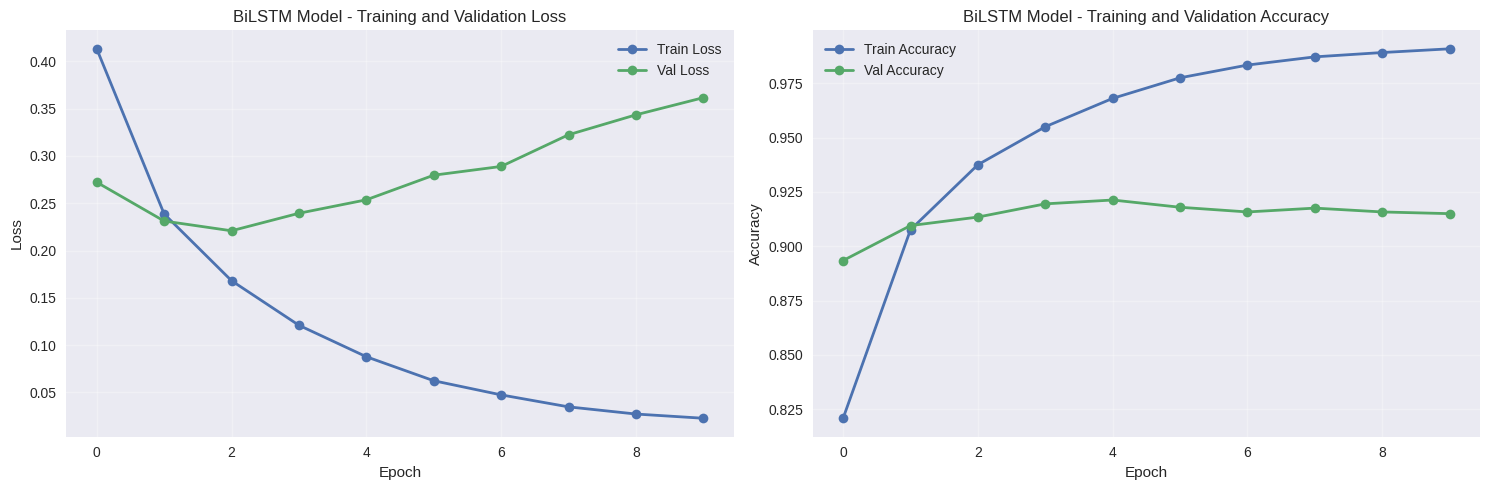

In [53]:
# ========================
# 8. PLOT TRAINING HISTORY - BiLSTMOnly
# ========================

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('BiLSTM Model - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('BiLSTM Model - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('BiLSTMOnly_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

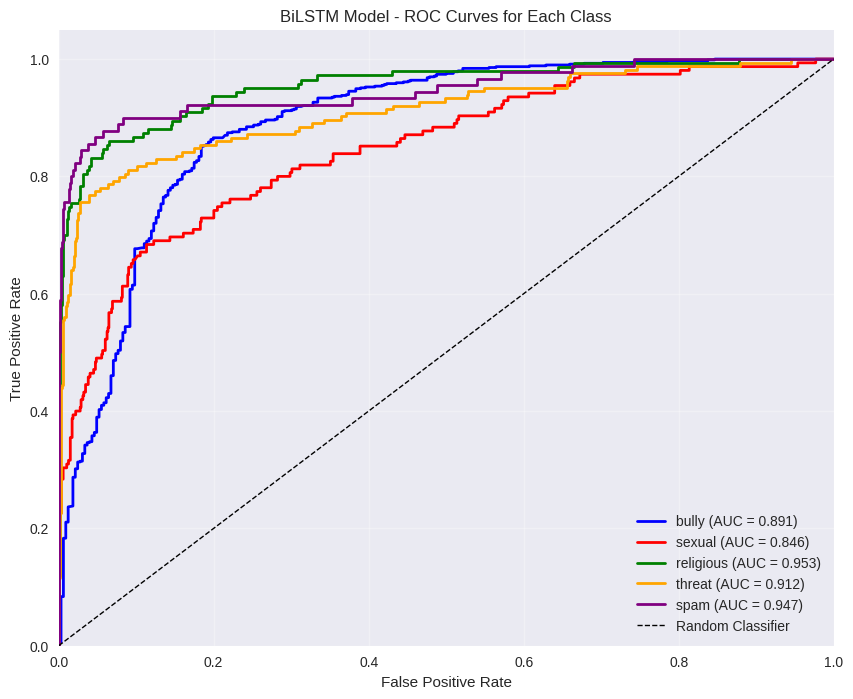

In [54]:
# ========================
# 9. PLOT ROC CURVES - BiLSTMOnly
# ========================

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, label in enumerate(label_cols):
    try:
        fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        plt.plot(fpr, tpr, color=colors[i], linewidth=2, 
                label=f'{label} (AUC = {auc:.3f})')
    except ValueError:
        continue

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('BiLSTM Model - ROC Curves for Each Class')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('BiLSTMOnly_ROC_curves.png', dpi=300, bbox_inches='tight')
plt.show()


COMPREHENSIVE CONFUSION MATRIX


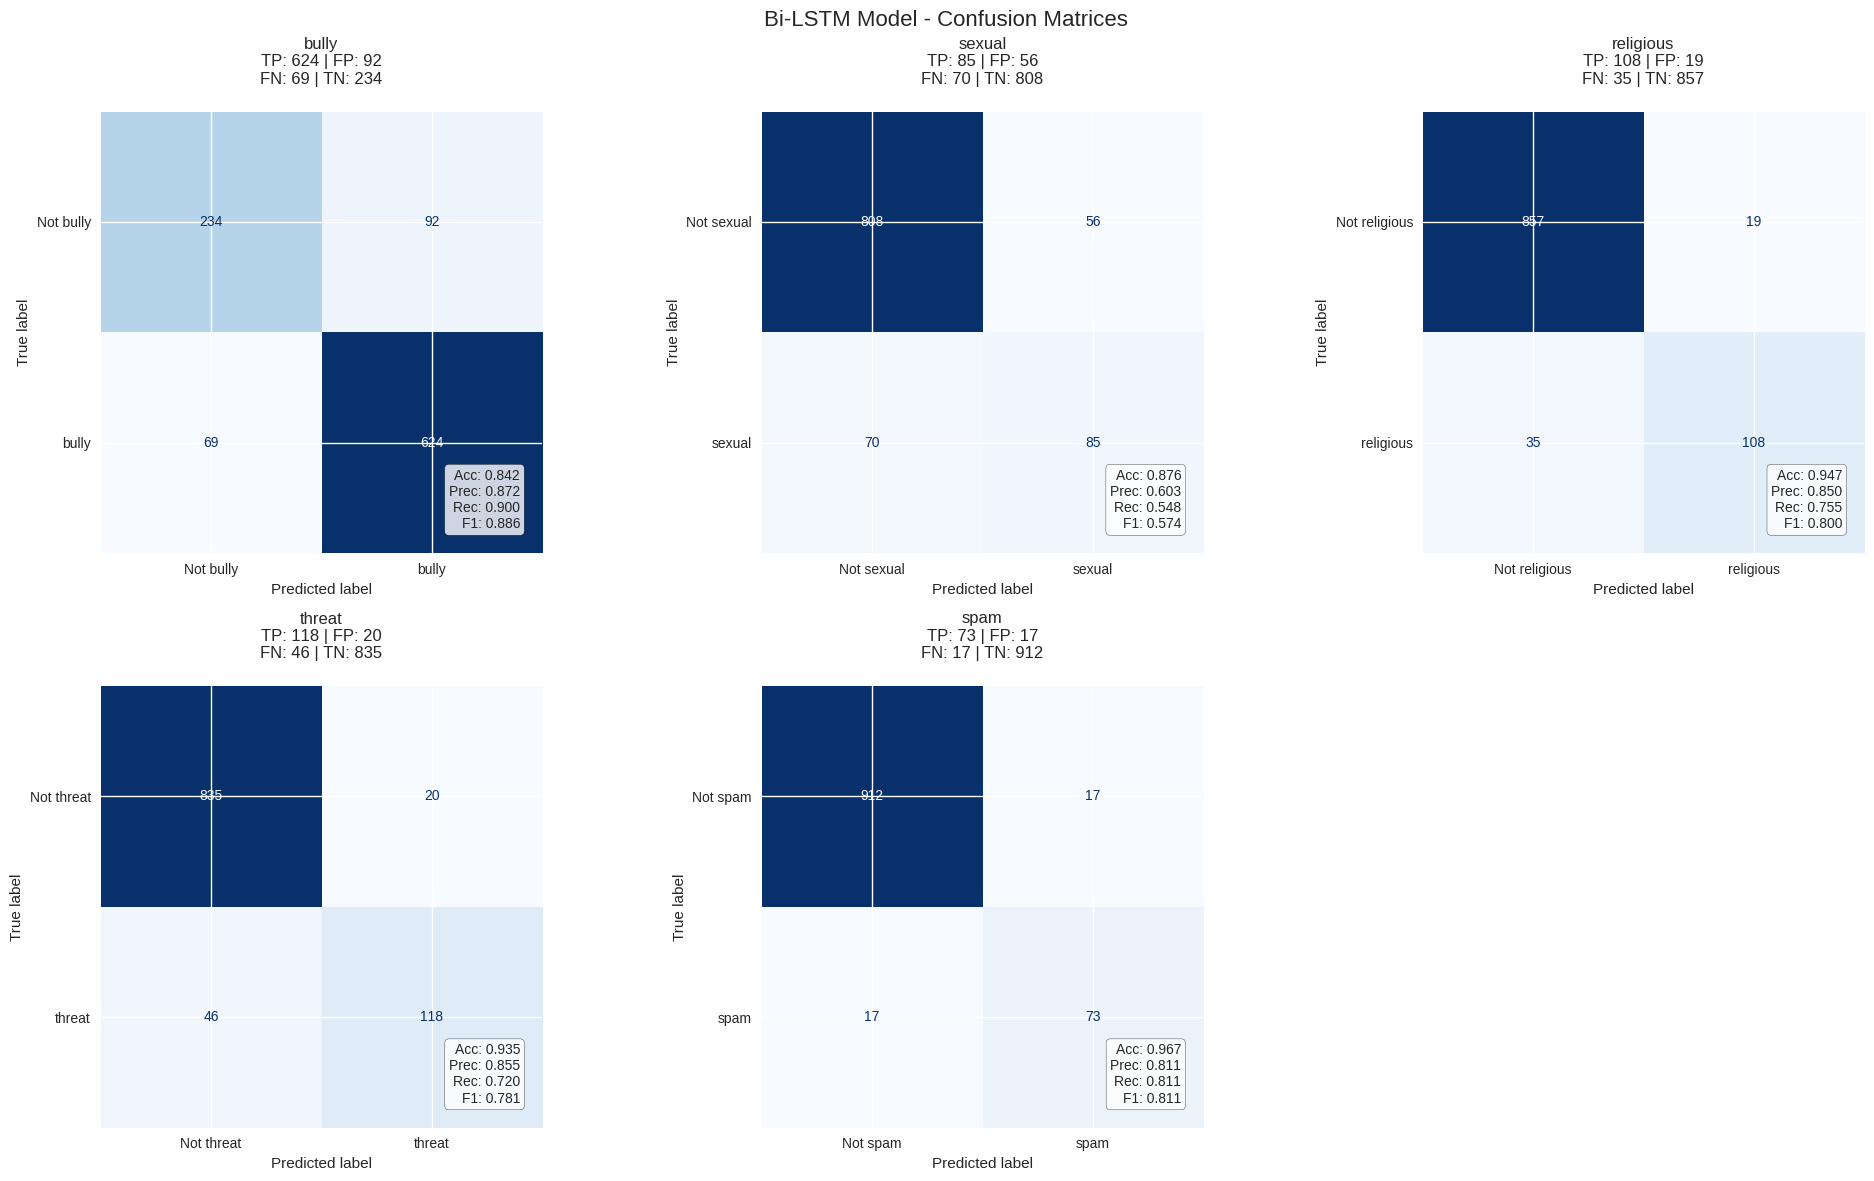

In [55]:
# Add this import at the top
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay

# ========================
# CONFUSION MATRIX SECTION 
# ========================

print(f"\n{'='*50}")
print("COMPREHENSIVE CONFUSION MATRIX")
print(f"{'='*50}")

# Create multilabel confusion matrix
mcm = multilabel_confusion_matrix(test_labels, test_preds)

# Plot a single comprehensive figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, (label, cm) in enumerate(zip(label_cols, mcm)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not '+label, label])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f'{label}\nTP: {cm[1,1]} | FP: {cm[0,1]}\nFN: {cm[1,0]} | TN: {cm[0,0]}', 
                     fontsize=12, pad=20)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # Add metrics as text
    metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
    axes[i].text(0.95, 0.05, metrics_text, transform=axes[i].transAxes, 
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10)

# Hide the last subplot if we have odd number of labels
if len(label_cols) < len(axes):
    for i in range(len(label_cols), len(axes)):
        axes[i].set_visible(False)

plt.suptitle('Bi-LSTM Model - Confusion Matrices', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()



In [56]:
# ========================
# 10. SAMPLE PREDICTIONS - BiLSTMOnly
# ========================

def predict_cyberbullying_bilstm(text, model, vocab, device, threshold=0.5):
    """Predict cyberbullying categories for a single text using BiLSTM model"""
    model.eval()
    
    # Tokenize and convert to indices
    tokens = text.split()[:MAX_LEN]
    input_ids = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    
    # Padding
    if len(input_ids) < MAX_LEN:
        input_ids = input_ids + [vocab['<PAD>']] * (MAX_LEN - len(input_ids))
    else:
        input_ids = input_ids[:MAX_LEN]
    
    input_ids = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(input_ids)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        preds = (probs > threshold).astype(int)
    
    results = {label: {'prediction': int(pred), 'probability': float(prob)} 
               for label, pred, prob in zip(label_cols, preds, probs)}
    
    return results

# Display 3 sample predictions from test data
print(f"\n{'='*50}")
print("SAMPLE PREDICTIONS FROM TEST DATA - BiLSTM")
print(f"{'='*50}")

# Get 3 random samples from test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 3, replace=False)

for i, idx in enumerate(sample_indices, 1):
    sample_text = X_test[idx]
    true_labels = y_test[idx]
    
    print(f"\nSample {i}:")
    print(f"Text: {sample_text}")
    
    # Get predictions
    predictions = predict_cyberbullying_bilstm(sample_text, model, vocab, device)
    
    print("Predictions:")
    for label in label_cols:
        pred = predictions[label]['prediction']
        prob = predictions[label]['probability']
        true = int(true_labels[label_cols.index(label)])
        
        status = "✓" if pred == true else "✗"
        print(f"  {label}: Pred={pred} (prob: {prob:.3f}), True={true}")


SAMPLE PREDICTIONS FROM TEST DATA - BiLSTM

Sample 1:
Text: চলচ্চিত্র জগতে জাহিদের কি অবদান আরেকজনকে কিভাবে অপমান করে তাকে জুতাপেটা করা দরকার
Predictions:
  bully: Pred=1 (prob: 0.997), True=1
  sexual: Pred=0 (prob: 0.016), True=0
  religious: Pred=0 (prob: 0.008), True=0
  threat: Pred=1 (prob: 1.000), True=1
  spam: Pred=0 (prob: 0.001), True=0

Sample 2:
Text: সবার সাপোর্ট চাই ভাই আইডিটা ফিরিয়ে গেছেএকটু সাপোর্ট কইরা দিয়েন
Predictions:
  bully: Pred=0 (prob: 0.000), True=0
  sexual: Pred=0 (prob: 0.000), True=0
  religious: Pred=0 (prob: 0.018), True=0
  threat: Pred=0 (prob: 0.000), True=0
  spam: Pred=1 (prob: 0.999), True=1

Sample 3:
Text: দুধটা খুইলা একটু ভালো করে করলা একটু মজা লাগবে
Predictions:
  bully: Pred=1 (prob: 1.000), True=1
  sexual: Pred=1 (prob: 0.974), True=1
  religious: Pred=0 (prob: 0.001), True=0
  threat: Pred=0 (prob: 0.001), True=0
  spam: Pred=0 (prob: 0.000), True=0


# ================== END ==========================

# ================ GRU ==========================

In [57]:
# ========================
# 3. MODEL ARCHITECTURE: GRU
# ========================

class GRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=256, num_layers=2, 
                 num_labels=5, dropout=0.3, padding_idx=0):
        super(GRU, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)
        
    def forward(self, input_ids, attention_mask=None):
        # input_ids shape: (batch_size, seq_length)
        embeddings = self.embedding(input_ids)  # (batch_size, seq_length, embedding_dim)
        
        gru_output, hidden = self.gru(embeddings)
        # Concatenate last hidden states from both directions
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        hidden = self.dropout(hidden)
        logits = self.classifier(hidden)
        return logits

In [58]:
# ========================
# 4. DATA PREPARATION FOR GRU
# ========================

class LSTMDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=64):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab  # This should be a dictionary
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Simple tokenization (split by space)
        tokens = text.split()[:self.max_len]
        
        # Convert tokens to indices - FIXED: directly access vocab dictionary
        input_ids = []
        for token in tokens:
            if token in self.vocab:
                input_ids.append(self.vocab[token])
            else:
                input_ids.append(self.vocab['<UNK>'])
        
        # Padding
        if len(input_ids) < self.max_len:
            input_ids = input_ids + [self.vocab['<PAD>']] * (self.max_len - len(input_ids))
        else:
            input_ids = input_ids[:self.max_len]
        
        attention_mask = [1 if token != self.vocab['<PAD>'] else 0 for token in input_ids]
        
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.float)
        }

In [59]:
def build_vocab(texts, min_freq=2):
    vocab = {'<PAD>': 0, '<UNK>': 1}
    word_freq = {}
    
    # Count word frequencies
    for text in texts:
        tokens = str(text).split()
        for token in tokens:
            word_freq[token] = word_freq.get(token, 0) + 1
    
    # Add words to vocabulary based on frequency
    idx = 2
    for word, freq in word_freq.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    
    return vocab

In [60]:
# ========================
# 5. MAIN TRAINING PIPELINE - GRU
# ========================

# Configuration
MAX_LEN = 64
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-3
EMBEDDING_DIM = 300
HIDDEN_DIM = 256
GRU_LAYERS = 2

# Build vocabulary from training data
print("Building vocabulary...")
vocab = build_vocab(X_train)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# Create datasets
train_dataset = LSTMDataset(X_train, y_train, vocab, MAX_LEN)
val_dataset = LSTMDataset(X_val, y_val, vocab, MAX_LEN)
test_dataset = LSTMDataset(X_test, y_test, vocab, MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Initialize GRU model
model = GRU(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=GRU_LAYERS,
    num_labels=len(label_cols)
).to(device)

print(f"\nModel: GRU")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Building vocabulary...
Vocabulary size: 5236

Model: GRU
Total parameters: 3,613,173


In [61]:
# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)


In [62]:

def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc='Training')
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        logits = model(input_ids, attention_mask)
        loss = nn.BCEWithLogitsLoss()(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        
        # Calculate accuracy
        preds = torch.sigmoid(logits) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy

def eval_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    progress_bar = tqdm(dataloader, desc='Validation')
    
    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            logits = model(input_ids, attention_mask)
            loss = nn.BCEWithLogitsLoss()(logits, labels)
            
            total_loss += loss.item()
            
            probs = torch.sigmoid(logits)
            preds = probs > 0.5
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)

In [63]:
# ========================
# 6. TRAINING LOOP - GRU
# ========================

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n" + "="*50)
print("STARTING TRAINING - GRU")
print("="*50)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    
    # Validate
    val_loss, val_acc, _, _, _ = eval_epoch(model, val_loader, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save last model checkpoint (not best)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'vocab': vocab,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc
    }, 'last_model_checkpoint_gru.pt')
    print(f"✓ Last GRU model checkpoint saved! (Epoch {epoch+1})")

print("\n" + "="*50)
print("TRAINING COMPLETED - GRU")
print("="*50)

# Print final training and validation metrics
print(f"\nFINAL TRAINING METRICS - GRU:")
print(f"Last Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Last Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Last Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Last Validation Accuracy: {history['val_acc'][-1]:.4f}")



STARTING TRAINING - GRU

Epoch 1/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.3970 | Train Acc: 0.8353
Val Loss: 0.2624 | Val Acc: 0.8960
✓ Last GRU model checkpoint saved! (Epoch 1)

Epoch 2/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0255 | Train Acc: 0.9896
Val Loss: 0.3258 | Val Acc: 0.9172
✓ Last GRU model checkpoint saved! (Epoch 9)

Epoch 10/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0210 | Train Acc: 0.9914
Val Loss: 0.3333 | Val Acc: 0.9134
✓ Last GRU model checkpoint saved! (Epoch 10)

TRAINING COMPLETED - GRU

FINAL TRAINING METRICS - GRU:
Last Train Loss: 0.0210
Last Train Accuracy: 0.9914
Last Validation Loss: 0.3333
Last Validation Accuracy: 0.9134


In [64]:
# ========================
# 7. TEST EVALUATION - GRU
# ========================

print("\n" + "="*50)
print("TESTING WITH LAST GRU MODEL")
print("="*50)

# # Load last model checkpoint
# checkpoint = torch.load('last_model_checkpoint_gru.pt')
# model.load_state_dict(checkpoint['model_state_dict'])

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels, test_probs = eval_epoch(model, test_loader, device)

print(f"\n{'='*50}")
print(f"TEST RESULTS - GRU")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Hamming Loss: {hamming_loss(test_labels, test_preds):.4f}")


TESTING WITH LAST GRU MODEL


Validation:   0%|          | 0/32 [00:00<?, ?it/s]


TEST RESULTS - GRU
Test Loss: 0.3440
Test Accuracy: 0.9132
Hamming Loss: 0.0868


In [65]:
# Calculate precision, recall, F1 scores
precision = precision_score(test_labels, test_preds, average='micro', zero_division=0)
recall = recall_score(test_labels, test_preds, average='micro', zero_division=0)
f1 = f1_score(test_labels, test_preds, average='micro', zero_division=0)

print(f"\nOverall Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Overall Metrics:
Precision: 0.8326
Recall: 0.8072
F1-Score: 0.8197


In [66]:

# ========================
# MCC AND COHEN'S KAPPA SCORES
# ========================

from sklearn.metrics import matthews_corrcoef, cohen_kappa_score
import numpy as np

# Convert to numpy arrays
test_labels_np = np.array(test_labels)
test_preds_np = np.array(test_preds)

class_names = ['bully', 'sexual', 'religious', 'threat', 'spam']

print(f"\n{'='*50}")
print(f"MCC AND COHEN'S KAPPA SCORES")
print(f"{'='*50}")

# Calculate for each class
mcc_scores = []
kappa_scores = []

print("\nPer-class Scores:")
for i, class_name in enumerate(class_names):
    mcc = matthews_corrcoef(test_labels_np[:, i], test_preds_np[:, i])
    kappa = cohen_kappa_score(test_labels_np[:, i], test_preds_np[:, i])
    
    mcc_scores.append(mcc)
    kappa_scores.append(kappa)
    
    print(f"{class_name:>10}: MCC = {mcc:.4f}, Cohen's Kappa = {kappa:.4f}")

# Calculate averages
average_mcc = np.mean(mcc_scores)
average_kappa = np.mean(kappa_scores)

print(f"\nAverage Scores:")
print(f"MCC: {average_mcc:.4f}")
print(f"Cohen's Kappa: {average_kappa:.4f}")


MCC AND COHEN'S KAPPA SCORES

Per-class Scores:
     bully: MCC = 0.6136, Cohen's Kappa = 0.6135
    sexual: MCC = 0.4952, Cohen's Kappa = 0.4941
 religious: MCC = 0.8126, Cohen's Kappa = 0.8120
    threat: MCC = 0.7602, Cohen's Kappa = 0.7591
      spam: MCC = 0.7724, Cohen's Kappa = 0.7715

Average Scores:
MCC: 0.6908
Cohen's Kappa: 0.6900


In [67]:
# Per-label metrics
print(f"\n{'='*50}")
print("PER-LABEL CLASSIFICATION REPORT - GRU")
print(f"{'='*50}")
print(classification_report(
    test_labels, 
    test_preds, 
    target_names=label_cols,
    zero_division=0
))



PER-LABEL CLASSIFICATION REPORT - GRU
              precision    recall  f1-score   support

       bully       0.87      0.88      0.88       693
      sexual       0.60      0.54      0.57       155
   religious       0.87      0.81      0.84       143
      threat       0.83      0.76      0.80       164
        spam       0.83      0.76      0.79        90

   micro avg       0.83      0.81      0.82      1245
   macro avg       0.80      0.75      0.77      1245
weighted avg       0.83      0.81      0.82      1245
 samples avg       0.69      0.67      0.66      1245



In [68]:
# Calculate AUC-ROC for each class
print(f"\n{'='*50}")
print("AUC-ROC SCORES FOR EACH CLASS - GRU")
print(f"{'='*50}")
for i, label in enumerate(label_cols):
    try:
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        print(f"{label}: {auc:.4f}")
    except ValueError:
        print(f"{label}: Could not calculate AUC (only one class present)")

# Calculate overall micro and macro AUC
try:
    micro_auc = roc_auc_score(test_labels, test_probs, average='micro')
    macro_auc = roc_auc_score(test_labels, test_probs, average='macro')
    print(f"\nMicro AUC: {micro_auc:.4f}")
    print(f"Macro AUC: {macro_auc:.4f}")
except ValueError:
    print("\nCould not calculate overall AUC scores")



AUC-ROC SCORES FOR EACH CLASS - GRU
bully: 0.8876
sexual: 0.8590
religious: 0.9546
threat: 0.9317
spam: 0.9614

Micro AUC: 0.9506
Macro AUC: 0.9188


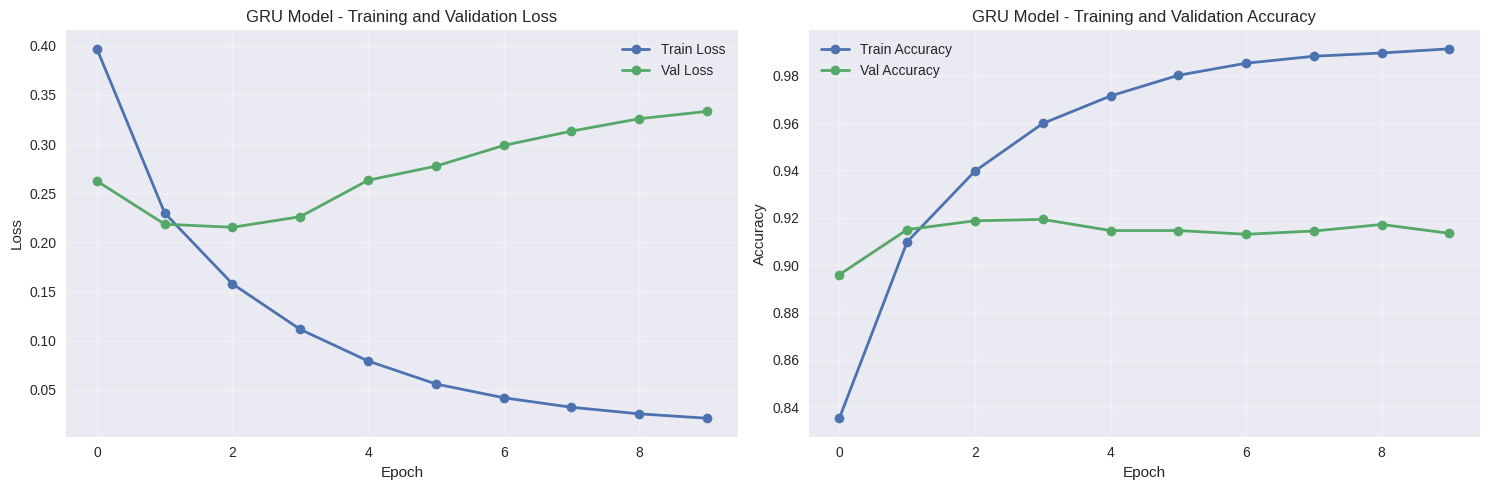

In [69]:
# ========================
# 8. PLOT TRAINING HISTORY - GRU
# ========================

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('GRU Model - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('GRU Model - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('GRU_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

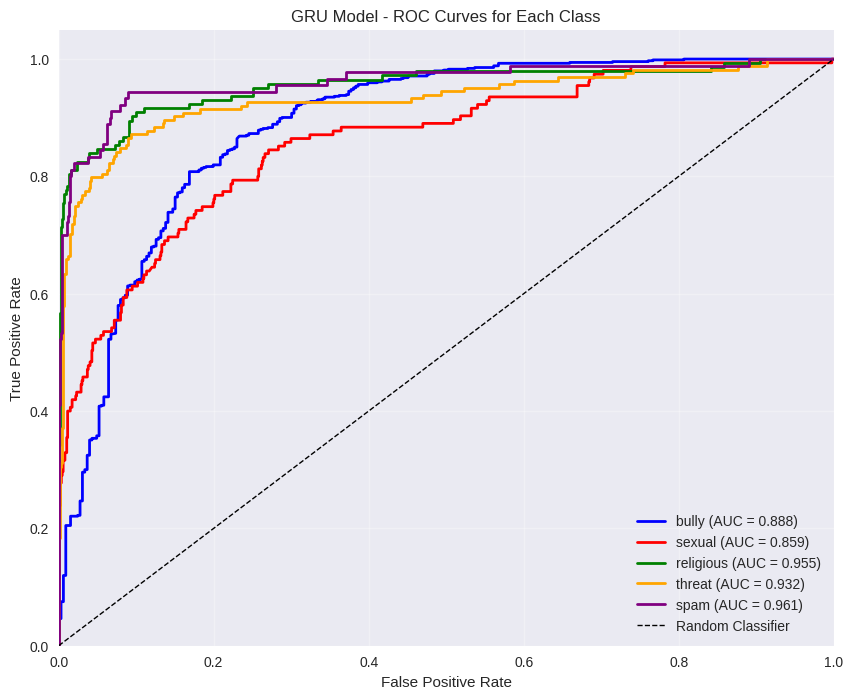

In [70]:
# ========================
# 9. PLOT ROC CURVES - GRU
# ========================

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, label in enumerate(label_cols):
    try:
        fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        plt.plot(fpr, tpr, color=colors[i], linewidth=2, 
                label=f'{label} (AUC = {auc:.3f})')
    except ValueError:
        continue

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('GRU Model - ROC Curves for Each Class')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('GRU_ROC_curves.png', dpi=300, bbox_inches='tight')
plt.show()


COMPREHENSIVE CONFUSION MATRIX


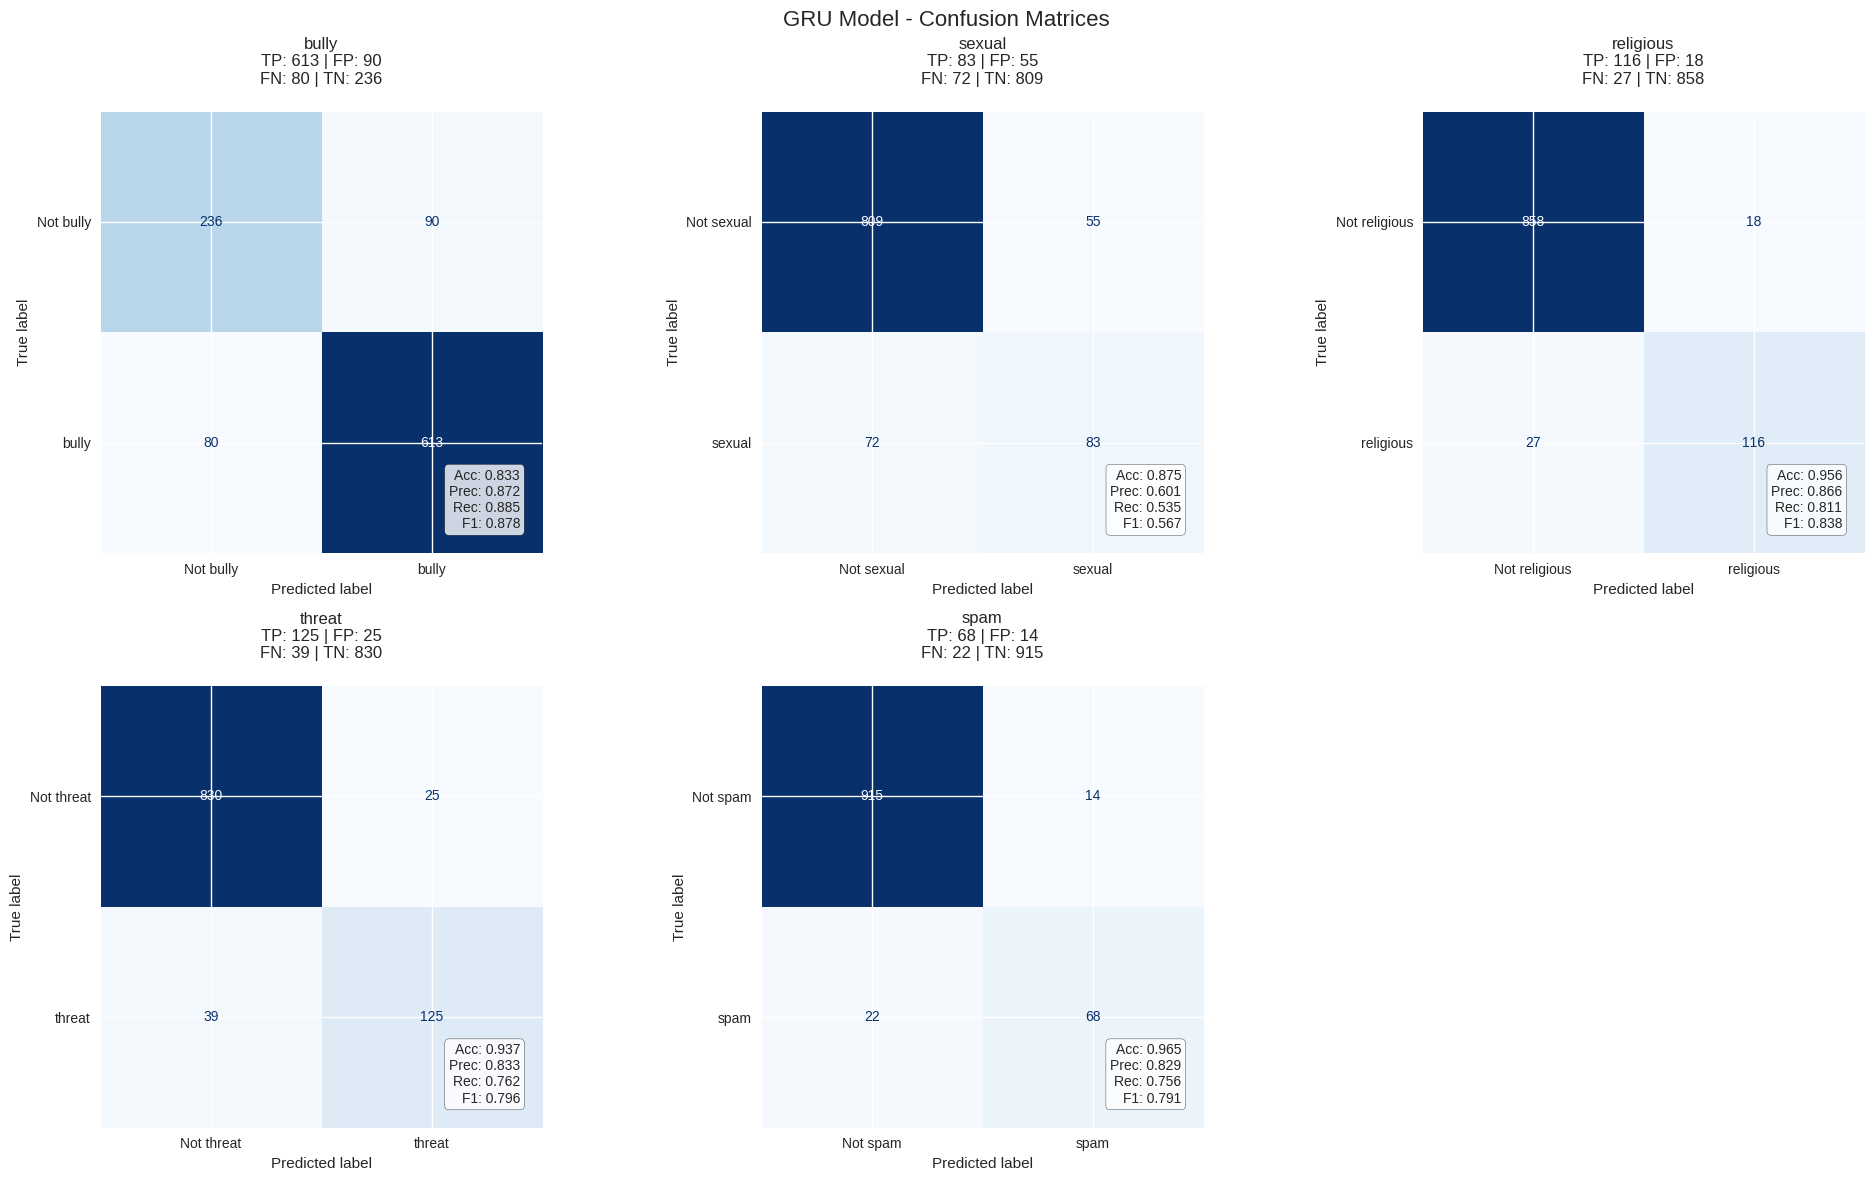

In [71]:
# Add this import at the top
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay

# ========================
# CONFUSION MATRIX SECTION 
# ========================

print(f"\n{'='*50}")
print("COMPREHENSIVE CONFUSION MATRIX")
print(f"{'='*50}")

# Create multilabel confusion matrix
mcm = multilabel_confusion_matrix(test_labels, test_preds)

# Plot a single comprehensive figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, (label, cm) in enumerate(zip(label_cols, mcm)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not '+label, label])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f'{label}\nTP: {cm[1,1]} | FP: {cm[0,1]}\nFN: {cm[1,0]} | TN: {cm[0,0]}', 
                     fontsize=12, pad=20)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # Add metrics as text
    metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
    axes[i].text(0.95, 0.05, metrics_text, transform=axes[i].transAxes, 
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10)

# Hide the last subplot if we have odd number of labels
if len(label_cols) < len(axes):
    for i in range(len(label_cols), len(axes)):
        axes[i].set_visible(False)

plt.suptitle('GRU Model - Confusion Matrices', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()



In [72]:
# ========================
# 10. SAMPLE PREDICTIONS - GRU
# ========================

def predict_cyberbullying_gru(text, model, vocab, device, threshold=0.5):
    """Predict cyberbullying categories for a single text using GRU model"""
    model.eval()
    
    # Tokenize and convert to indices
    tokens = text.split()[:MAX_LEN]
    input_ids = []
    for token in tokens:
        if token in vocab:
            input_ids.append(vocab[token])
        else:
            input_ids.append(vocab['<UNK>'])
    
    # Padding
    if len(input_ids) < MAX_LEN:
        input_ids = input_ids + [vocab['<PAD>']] * (MAX_LEN - len(input_ids))
    else:
        input_ids = input_ids[:MAX_LEN]
    
    input_ids = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(input_ids)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        preds = (probs > threshold).astype(int)
    
    results = {label: {'prediction': int(pred), 'probability': float(prob)} 
               for label, pred, prob in zip(label_cols, preds, probs)}
    
    return results

# Display 3 sample predictions from test data
print(f"\n{'='*50}")
print("SAMPLE PREDICTIONS FROM TEST DATA - GRU")
print(f"{'='*50}")

# Get 3 random samples from test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 3, replace=False)

for i, idx in enumerate(sample_indices, 1):
    sample_text = X_test[idx]
    true_labels = y_test[idx]
    
    print(f"\nSample {i}:")
    print(f"Text: {sample_text}")
    
    # Get predictions
    predictions = predict_cyberbullying_gru(sample_text, model, vocab, device)
    
    print("Predictions:")
    for label in label_cols:
        pred = predictions[label]['prediction']
        prob = predictions[label]['probability']
        true = int(true_labels[label_cols.index(label)])
        
        status = "✓" if pred == true else "✗"
        print(f"  {label}: {status} Pred={pred} (prob: {prob:.3f}), True={true}")


SAMPLE PREDICTIONS FROM TEST DATA - GRU

Sample 1:
Text: চলচ্চিত্র জগতে জাহিদের কি অবদান আরেকজনকে কিভাবে অপমান করে তাকে জুতাপেটা করা দরকার
Predictions:
  bully: ✓ Pred=1 (prob: 1.000), True=1
  sexual: ✓ Pred=0 (prob: 0.009), True=0
  religious: ✓ Pred=0 (prob: 0.002), True=0
  threat: ✓ Pred=1 (prob: 0.997), True=1
  spam: ✓ Pred=0 (prob: 0.000), True=0

Sample 2:
Text: সবার সাপোর্ট চাই ভাই আইডিটা ফিরিয়ে গেছেএকটু সাপোর্ট কইরা দিয়েন
Predictions:
  bully: ✓ Pred=0 (prob: 0.000), True=0
  sexual: ✓ Pred=0 (prob: 0.000), True=0
  religious: ✓ Pred=0 (prob: 0.003), True=0
  threat: ✓ Pred=0 (prob: 0.000), True=0
  spam: ✓ Pred=1 (prob: 0.999), True=1

Sample 3:
Text: দুধটা খুইলা একটু ভালো করে করলা একটু মজা লাগবে
Predictions:
  bully: ✓ Pred=1 (prob: 0.992), True=1
  sexual: ✓ Pred=1 (prob: 0.983), True=1
  religious: ✓ Pred=0 (prob: 0.000), True=0
  threat: ✓ Pred=0 (prob: 0.001), True=0
  spam: ✓ Pred=0 (prob: 0.017), True=0


# =============== END ==============

# ===================== Bi-GRU ============================

In [73]:
# ========================
# 2. TRAINING FUNCTIONS
# ========================

def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc='Training')
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        logits = model(input_ids, attention_mask)
        loss = nn.BCEWithLogitsLoss()(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        
        # Calculate accuracy
        preds = torch.sigmoid(logits) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy

def eval_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    progress_bar = tqdm(dataloader, desc='Validation')
    
    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            logits = model(input_ids, attention_mask)
            loss = nn.BCEWithLogitsLoss()(logits, labels)
            
            total_loss += loss.item()
            
            probs = torch.sigmoid(logits)
            preds = probs > 0.5
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)

# ========================
# 3. MODEL ARCHITECTURE: Bi-GRU
# ========================

class BiGRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=256, num_layers=2, 
                 num_labels=5, dropout=0.3, padding_idx=0):
        super(BiGRU, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)
        
    def forward(self, input_ids, attention_mask=None):
        # input_ids shape: (batch_size, seq_length)
        embeddings = self.embedding(input_ids)  # (batch_size, seq_length, embedding_dim)
        
        gru_output, hidden = self.gru(embeddings)
        # Concatenate last hidden states from both directions
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        hidden = self.dropout(hidden)
        logits = self.classifier(hidden)
        return logits

In [74]:
# ========================
# 4. DATA PREPARATION FOR Bi-GRU
# ========================

class LSTMDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=64):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab  # This should be a dictionary
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Simple tokenization (split by space)
        tokens = text.split()[:self.max_len]
        
        # Convert tokens to indices - FIXED: directly access vocab dictionary
        input_ids = []
        for token in tokens:
            if token in self.vocab:
                input_ids.append(self.vocab[token])
            else:
                input_ids.append(self.vocab['<UNK>'])
        
        # Padding
        if len(input_ids) < self.max_len:
            input_ids = input_ids + [self.vocab['<PAD>']] * (self.max_len - len(input_ids))
        else:
            input_ids = input_ids[:self.max_len]
        
        attention_mask = [1 if token != self.vocab['<PAD>'] else 0 for token in input_ids]
        
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.float)
        }

def build_vocab(texts, min_freq=2):
    vocab = {'<PAD>': 0, '<UNK>': 1}
    word_freq = {}
    
    # Count word frequencies
    for text in texts:
        tokens = str(text).split()
        for token in tokens:
            word_freq[token] = word_freq.get(token, 0) + 1
    
    # Add words to vocabulary based on frequency
    idx = 2
    for word, freq in word_freq.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    
    return vocab


In [75]:
# ========================
# 5. MAIN TRAINING PIPELINE - Bi-GRU
# ========================

# Configuration
MAX_LEN = 64
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-3
EMBEDDING_DIM = 300
HIDDEN_DIM = 256
GRU_LAYERS = 2

# Build vocabulary from training data
print("Building vocabulary...")
vocab = build_vocab(X_train)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# Create datasets
train_dataset = LSTMDataset(X_train, y_train, vocab, MAX_LEN)
val_dataset = LSTMDataset(X_val, y_val, vocab, MAX_LEN)
test_dataset = LSTMDataset(X_test, y_test, vocab, MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Initialize Bi-GRU model
model = BiGRU(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=GRU_LAYERS,
    num_labels=len(label_cols)
).to(device)

print(f"\nModel: BiGRU")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


Building vocabulary...
Vocabulary size: 5236

Model: BiGRU
Total parameters: 3,613,173


In [76]:
# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

In [77]:
# ========================
# 6. TRAINING LOOP - Bi-GRU
# ========================

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n" + "="*50)
print("STARTING TRAINING - BiGRU")
print("="*50)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    
    # Validate
    val_loss, val_acc, _, _, _ = eval_epoch(model, val_loader, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save last model checkpoint (not best)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'vocab': vocab,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc
    }, 'last_model_checkpoint_bigru.pt')
    print(f"✓ Last BiGRU model checkpoint saved! (Epoch {epoch+1})")

print("\n" + "="*50)
print("TRAINING COMPLETED - BiGRU")
print("="*50)

# Print final training and validation metrics
print(f"\nFINAL TRAINING METRICS - BiGRU:")
print(f"Last Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Last Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Last Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Last Validation Accuracy: {history['val_acc'][-1]:.4f}")


STARTING TRAINING - BiGRU

Epoch 1/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.3978 | Train Acc: 0.8283
Val Loss: 0.2701 | Val Acc: 0.8915
✓ Last BiGRU model checkpoint saved! (Epoch 1)

Epoch 2/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0251 | Train Acc: 0.9904
Val Loss: 0.3451 | Val Acc: 0.9127
✓ Last BiGRU model checkpoint saved! (Epoch 9)

Epoch 10/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0215 | Train Acc: 0.9909
Val Loss: 0.3520 | Val Acc: 0.9125
✓ Last BiGRU model checkpoint saved! (Epoch 10)

TRAINING COMPLETED - BiGRU

FINAL TRAINING METRICS - BiGRU:
Last Train Loss: 0.0215
Last Train Accuracy: 0.9909
Last Validation Loss: 0.3520
Last Validation Accuracy: 0.9125


In [78]:
# ========================
# 7. TEST EVALUATION - Bi-GRU
# ========================

print("\n" + "="*50)
print("TESTING WITH LAST BiGRU MODEL")
print("="*50)

# # Load last model checkpoint
# checkpoint = torch.load('last_model_checkpoint_bigru.pt')
# model.load_state_dict(checkpoint['model_state_dict'])

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels, test_probs = eval_epoch(model, test_loader, device)

print(f"\n{'='*50}")
print(f"TEST RESULTS - BiGRU")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Hamming Loss: {hamming_loss(test_labels, test_preds):.4f}")



TESTING WITH LAST BiGRU MODEL


Validation:   0%|          | 0/32 [00:00<?, ?it/s]


TEST RESULTS - BiGRU
Test Loss: 0.3566
Test Accuracy: 0.9138
Hamming Loss: 0.0862


In [79]:
# Calculate precision, recall, F1 scores
precision = precision_score(test_labels, test_preds, average='micro', zero_division=0)
recall = recall_score(test_labels, test_preds, average='micro', zero_division=0)
f1 = f1_score(test_labels, test_preds, average='micro', zero_division=0)

print(f"\nOverall Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Overall Metrics:
Precision: 0.8287
Recall: 0.8161
F1-Score: 0.8223


In [80]:
# Per-label metrics
print(f"\n{'='*50}")
print("PER-LABEL CLASSIFICATION REPORT - BiGRU")
print(f"{'='*50}")
print(classification_report(
    test_labels, 
    test_preds, 
    target_names=label_cols,
    zero_division=0
))


PER-LABEL CLASSIFICATION REPORT - BiGRU
              precision    recall  f1-score   support

       bully       0.87      0.89      0.88       693
      sexual       0.61      0.59      0.60       155
   religious       0.87      0.75      0.80       143
      threat       0.81      0.76      0.79       164
        spam       0.84      0.80      0.82        90

   micro avg       0.83      0.82      0.82      1245
   macro avg       0.80      0.76      0.78      1245
weighted avg       0.83      0.82      0.82      1245
 samples avg       0.69      0.67      0.67      1245



In [81]:

# ========================
# MCC AND COHEN'S KAPPA SCORES
# ========================

from sklearn.metrics import matthews_corrcoef, cohen_kappa_score
import numpy as np

# Convert to numpy arrays
test_labels_np = np.array(test_labels)
test_preds_np = np.array(test_preds)

class_names = ['bully', 'sexual', 'religious', 'threat', 'spam']

print(f"\n{'='*50}")
print(f"MCC AND COHEN'S KAPPA SCORES")
print(f"{'='*50}")

# Calculate for each class
mcc_scores = []
kappa_scores = []

print("\nPer-class Scores:")
for i, class_name in enumerate(class_names):
    mcc = matthews_corrcoef(test_labels_np[:, i], test_preds_np[:, i])
    kappa = cohen_kappa_score(test_labels_np[:, i], test_preds_np[:, i])
    
    mcc_scores.append(mcc)
    kappa_scores.append(kappa)
    
    print(f"{class_name:>10}: MCC = {mcc:.4f}, Cohen's Kappa = {kappa:.4f}")

# Calculate averages
average_mcc = np.mean(mcc_scores)
average_kappa = np.mean(kappa_scores)

print(f"\nAverage Scores:")
print(f"MCC: {average_mcc:.4f}")
print(f"Cohen's Kappa: {average_kappa:.4f}")


MCC AND COHEN'S KAPPA SCORES

Per-class Scores:
     bully: MCC = 0.6252, Cohen's Kappa = 0.6247
    sexual: MCC = 0.5283, Cohen's Kappa = 0.5283
 religious: MCC = 0.7783, Cohen's Kappa = 0.7754
    threat: MCC = 0.7472, Cohen's Kappa = 0.7467
      spam: MCC = 0.8013, Cohen's Kappa = 0.8010

Average Scores:
MCC: 0.6960
Cohen's Kappa: 0.6952


In [82]:
# Calculate AUC-ROC for each class
print(f"\n{'='*50}")
print("AUC-ROC SCORES FOR EACH CLASS - BiGRU")
print(f"{'='*50}")
for i, label in enumerate(label_cols):
    try:
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        print(f"{label}: {auc:.4f}")
    except ValueError:
        print(f"{label}: Could not calculate AUC (only one class present)")

# Calculate overall micro and macro AUC
try:
    micro_auc = roc_auc_score(test_labels, test_probs, average='micro')
    macro_auc = roc_auc_score(test_labels, test_probs, average='macro')
    print(f"\nMicro AUC: {micro_auc:.4f}")
    print(f"Macro AUC: {macro_auc:.4f}")
except ValueError:
    print("\nCould not calculate overall AUC scores")


AUC-ROC SCORES FOR EACH CLASS - BiGRU
bully: 0.8830
sexual: 0.8636
religious: 0.9488
threat: 0.9252
spam: 0.9595

Micro AUC: 0.9475
Macro AUC: 0.9160


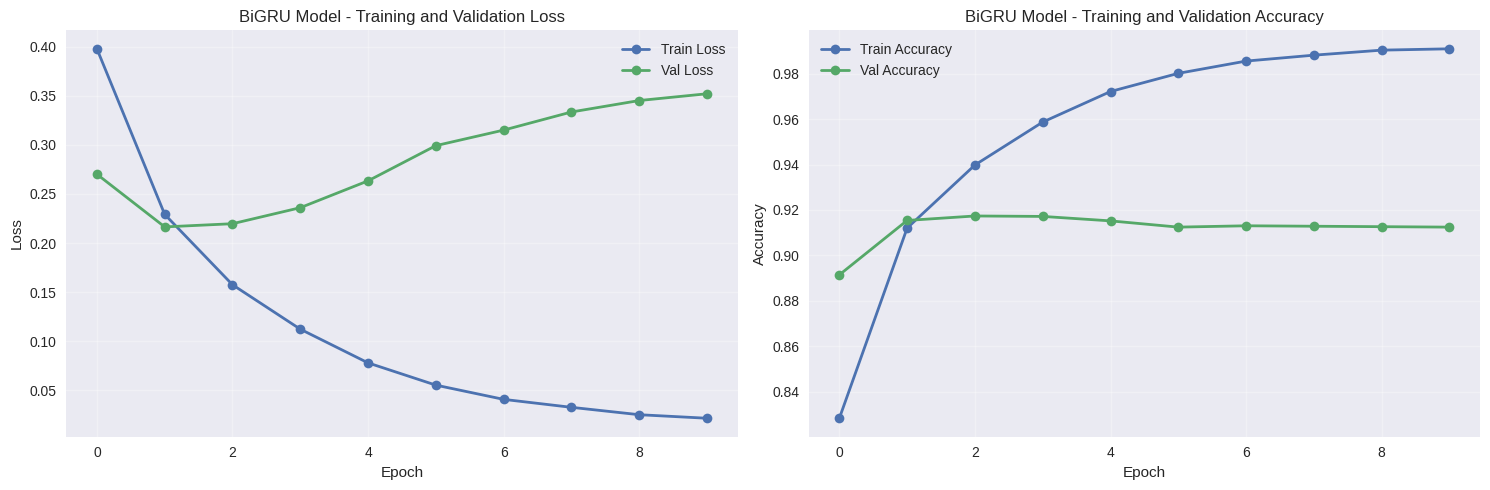

In [83]:
# ========================
# 8. PLOT TRAINING HISTORY - Bi-GRU
# ========================

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('BiGRU Model - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('BiGRU Model - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('BiGRU_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

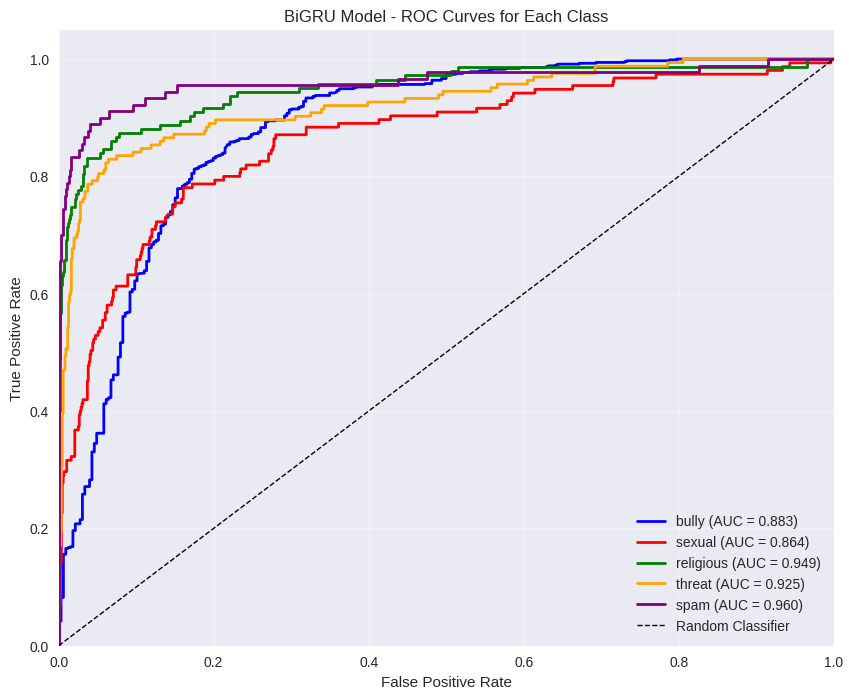

In [84]:
# ========================
# 9. PLOT ROC CURVES - Bi-GRU
# ========================

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, label in enumerate(label_cols):
    try:
        fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        plt.plot(fpr, tpr, color=colors[i], linewidth=2, 
                label=f'{label} (AUC = {auc:.3f})')
    except ValueError:
        continue

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('BiGRU Model - ROC Curves for Each Class')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('BiGRU_ROC_curves.png', dpi=300, bbox_inches='tight')
plt.show()


COMPREHENSIVE CONFUSION MATRIX


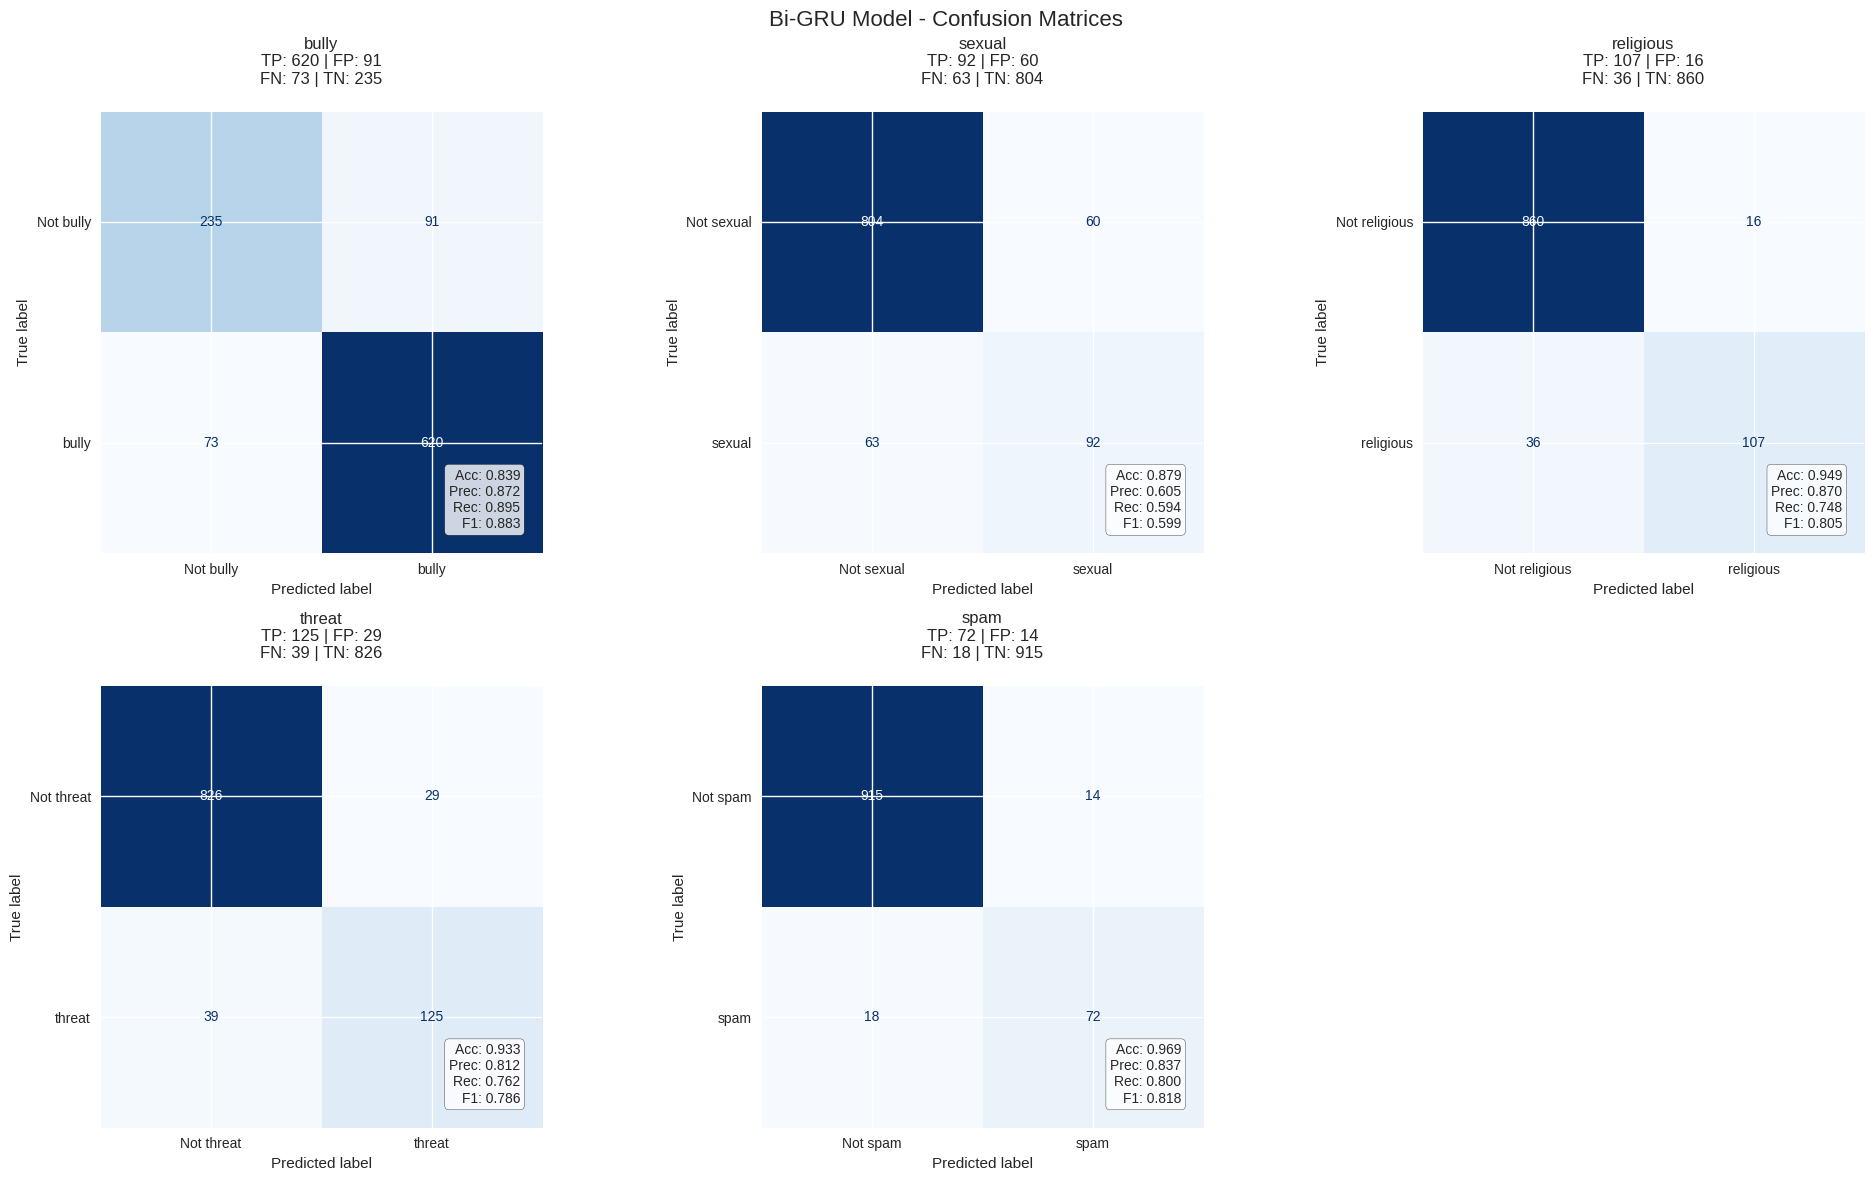

In [85]:
# Add this import at the top
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay

# ========================
# CONFUSION MATRIX SECTION 
# ========================

print(f"\n{'='*50}")
print("COMPREHENSIVE CONFUSION MATRIX")
print(f"{'='*50}")

# Create multilabel confusion matrix
mcm = multilabel_confusion_matrix(test_labels, test_preds)

# Plot a single comprehensive figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, (label, cm) in enumerate(zip(label_cols, mcm)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not '+label, label])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f'{label}\nTP: {cm[1,1]} | FP: {cm[0,1]}\nFN: {cm[1,0]} | TN: {cm[0,0]}', 
                     fontsize=12, pad=20)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # Add metrics as text
    metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
    axes[i].text(0.95, 0.05, metrics_text, transform=axes[i].transAxes, 
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10)

# Hide the last subplot if we have odd number of labels
if len(label_cols) < len(axes):
    for i in range(len(label_cols), len(axes)):
        axes[i].set_visible(False)

plt.suptitle('Bi-GRU Model - Confusion Matrices', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()



In [86]:
# ========================
# 10. SAMPLE PREDICTIONS - Bi-GRU
# ========================

def predict_cyberbullying_bigru(text, model, vocab, device, threshold=0.5):
    """Predict cyberbullying categories for a single text using BiGRU model"""
    model.eval()
    
    # Tokenize and convert to indices
    tokens = text.split()[:MAX_LEN]
    input_ids = []
    for token in tokens:
        if token in vocab:
            input_ids.append(vocab[token])
        else:
            input_ids.append(vocab['<UNK>'])
    
    # Padding
    if len(input_ids) < MAX_LEN:
        input_ids = input_ids + [vocab['<PAD>']] * (MAX_LEN - len(input_ids))
    else:
        input_ids = input_ids[:MAX_LEN]
    
    input_ids = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(input_ids)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        preds = (probs > threshold).astype(int)
    
    results = {label: {'prediction': int(pred), 'probability': float(prob)} 
               for label, pred, prob in zip(label_cols, preds, probs)}
    
    return results

# Display 3 sample predictions from test data
print(f"\n{'='*50}")
print("SAMPLE PREDICTIONS FROM TEST DATA - BiGRU")
print(f"{'='*50}")

# Get 3 random samples from test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 3, replace=False)

for i, idx in enumerate(sample_indices, 1):
    sample_text = X_test[idx]
    true_labels = y_test[idx]
    
    print(f"\nSample {i}:")
    print(f"Text: {sample_text}")
    
    # Get predictions
    predictions = predict_cyberbullying_bigru(sample_text, model, vocab, device)
    
    print("Predictions:")
    for label in label_cols:
        pred = predictions[label]['prediction']
        prob = predictions[label]['probability']
        true = int(true_labels[label_cols.index(label)])
        
        status = "✓" if pred == true else "✗"
        print(f"  {label}: {status} Pred={pred} (prob: {prob:.3f}), True={true}")


SAMPLE PREDICTIONS FROM TEST DATA - BiGRU

Sample 1:
Text: চলচ্চিত্র জগতে জাহিদের কি অবদান আরেকজনকে কিভাবে অপমান করে তাকে জুতাপেটা করা দরকার
Predictions:
  bully: ✓ Pred=1 (prob: 0.999), True=1
  sexual: ✓ Pred=0 (prob: 0.000), True=0
  religious: ✓ Pred=0 (prob: 0.001), True=0
  threat: ✓ Pred=1 (prob: 0.996), True=1
  spam: ✓ Pred=0 (prob: 0.000), True=0

Sample 2:
Text: সবার সাপোর্ট চাই ভাই আইডিটা ফিরিয়ে গেছেএকটু সাপোর্ট কইরা দিয়েন
Predictions:
  bully: ✓ Pred=0 (prob: 0.000), True=0
  sexual: ✓ Pred=0 (prob: 0.000), True=0
  religious: ✓ Pred=0 (prob: 0.012), True=0
  threat: ✓ Pred=0 (prob: 0.000), True=0
  spam: ✓ Pred=1 (prob: 0.999), True=1

Sample 3:
Text: দুধটা খুইলা একটু ভালো করে করলা একটু মজা লাগবে
Predictions:
  bully: ✓ Pred=1 (prob: 0.994), True=1
  sexual: ✓ Pred=1 (prob: 0.965), True=1
  religious: ✓ Pred=0 (prob: 0.000), True=0
  threat: ✓ Pred=0 (prob: 0.004), True=0
  spam: ✓ Pred=0 (prob: 0.015), True=0


# ================== END ======================

# ================ Machine learning based Models ==========================

In [87]:
# Bengali Multilabel Cyberbullying Detection with Traditional ML Models
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, hamming_loss, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [88]:
# ========================
# 2. TF-IDF VECTORIZATION
# ========================

print("\n" + "="*50)
print("TF-IDF VECTORIZATION")
print("="*50)

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words=None  # For Bengali, you might want to add custom stop words
)

# Fit and transform on training data
print("Fitting TF-IDF vectorizer...")
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF features: {X_train_tfidf.shape[1]}")
print(f"Train TF-IDF shape: {X_train_tfidf.shape}")
print(f"Val TF-IDF shape: {X_val_tfidf.shape}")
print(f"Test TF-IDF shape: {X_test_tfidf.shape}")


TF-IDF VECTORIZATION
Fitting TF-IDF vectorizer...
TF-IDF features: 5701
Train TF-IDF shape: (8150, 5701)
Val TF-IDF shape: (1019, 5701)
Test TF-IDF shape: (1019, 5701)


In [90]:
# ========================
# 3. MODEL DEFINITIONS
# ========================

models = {
    'Naive Bayes': MultiOutputClassifier(MultinomialNB()),
    'Random Forest': MultiOutputClassifier(RandomForestClassifier()),
    'K-Nearest Neighbors': MultiOutputClassifier(KNeighborsClassifier(
    )),
    'Logistic Regression': MultiOutputClassifier(LogisticRegression()),
    'XGBoost': MultiOutputClassifier(XGBClassifier())
}

In [91]:
from sklearn.metrics import (
    hamming_loss, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, matthews_corrcoef, cohen_kappa_score
)
import numpy as np

# ========================
# 4. TRAINING AND EVALUATION FUNCTION (with MCC & Kappa)
# ========================

def train_and_evaluate_models(models, X_train, y_train, X_test, y_test, label_cols):
    results = {}
    
    for model_name, model in models.items():
        print(f"\n{'='*50}")
        print(f"TRAINING: {model_name}")
        print(f"{'='*50}")
        
        # Train model
        print(f"Training {model_name}...")
        model.fit(X_train, y_train)
        
        # Predict on test set
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)
        
        # Convert probability predictions to proper format
        y_pred_proba_processed = []
        for i in range(len(label_cols)):
            if hasattr(y_pred_proba[i], 'shape') and len(y_pred_proba[i].shape) > 1:
                y_pred_proba_processed.append(y_pred_proba[i][:, 1])
            else:
                y_pred_proba_processed.append(y_pred_proba[i])
        
        y_pred_proba_processed = np.array(y_pred_proba_processed).T
        
        # Calculate metrics
        accuracy = np.mean(y_pred == y_test)
        h_loss = hamming_loss(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='micro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='micro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='micro', zero_division=0)
        
        # Calculate AUC-ROC for each class
        auc_scores = {}
        for i, label in enumerate(label_cols):
            try:
                auc = roc_auc_score(y_test[:, i], y_pred_proba_processed[:, i])
                auc_scores[label] = auc
            except ValueError:
                auc_scores[label] = np.nan
        
        # Calculate micro and macro AUC
        try:
            micro_auc = roc_auc_score(y_test, y_pred_proba_processed, average='micro')
            macro_auc = roc_auc_score(y_test, y_pred_proba_processed, average='macro')
        except ValueError:
            micro_auc = np.nan
            macro_auc = np.nan

        # ======================================================
        # Per-class MCC and Cohen's Kappa
        # ======================================================
        mcc_scores = {}
        kappa_scores = {}

        for i, label in enumerate(label_cols):
            try:
                mcc = matthews_corrcoef(y_test[:, i], y_pred[:, i])
                kappa = cohen_kappa_score(y_test[:, i], y_pred[:, i])
                mcc_scores[label] = mcc
                kappa_scores[label] = kappa
            except ValueError:
                mcc_scores[label] = np.nan
                kappa_scores[label] = np.nan

        avg_mcc = np.nanmean(list(mcc_scores.values()))
        avg_kappa = np.nanmean(list(kappa_scores.values()))
        
        # Store results
        results[model_name] = {
            'model': model,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba_processed,
            'accuracy': accuracy,
            'hamming_loss': h_loss,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'auc_scores': auc_scores,
            'micro_auc': micro_auc,
            'macro_auc': macro_auc,
            'mcc_scores': mcc_scores,
            'kappa_scores': kappa_scores,
            'avg_mcc': avg_mcc,
            'avg_kappa': avg_kappa
        }
        
        # Print results
        print(f"\n{model_name} Results:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Hamming Loss: {h_loss:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(f"Micro AUC: {micro_auc:.4f}")
        print(f"Macro AUC: {macro_auc:.4f}")
        
        print(f"\nPer-class AUC scores:")
        for label, auc in auc_scores.items():
            print(f"  {label}: {auc:.4f}")

        print(f"\nPer-class MCC & Cohen's Kappa:")
        for label in label_cols:
            print(f"  {label}: MCC = {mcc_scores[label]:.4f}, Cohen's Kappa = {kappa_scores[label]:.4f}")

        print(f"\nAverage Scores:")
        print(f"MCC: {avg_mcc:.4f}")
        print(f"Cohen's Kappa: {avg_kappa:.4f}")
        
        print(f"\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=label_cols, zero_division=0))
    
    return results


In [92]:
# ========================
# 5. TRAIN ALL MODELS
# ========================

print("\n" + "="*50)
print("TRAINING ALL ML MODELS")
print("="*50)

results = train_and_evaluate_models(models, X_train_tfidf, y_train, X_test_tfidf, y_test, label_cols)


TRAINING ALL ML MODELS

TRAINING: Naive Bayes
Training Naive Bayes...

Naive Bayes Results:
Accuracy: 0.8726
Hamming Loss: 0.1274
Precision: 0.8111
Recall: 0.6241
F1-Score: 0.7054
Micro AUC: 0.9041
Macro AUC: 0.8459

Per-class AUC scores:
  bully: 0.8520
  sexual: 0.7794
  religious: 0.8692
  threat: 0.8205
  spam: 0.9087

Per-class MCC & Cohen's Kappa:
  bully: MCC = 0.5068, Cohen's Kappa = 0.4718
  sexual: MCC = 0.3341, Cohen's Kappa = 0.2008
  religious: MCC = 0.5537, Cohen's Kappa = 0.4851
  threat: MCC = 0.2859, Cohen's Kappa = 0.1601
  spam: MCC = 0.5083, Cohen's Kappa = 0.4292

Average Scores:
MCC: 0.4377
Cohen's Kappa: 0.3494

Classification Report:
              precision    recall  f1-score   support

       bully       0.79      0.95      0.86       693
      sexual       1.00      0.13      0.23       155
   religious       0.95      0.36      0.53       143
      threat       0.94      0.10      0.19       164
        spam       0.93      0.30      0.45        90

   micr

In [93]:
# ========================
# 6. COMPARATIVE ANALYSIS
# ========================

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

# Create comparison dataframe
comparison_data = []
for model_name, result in results.items():
    comparison_data.append({
        'Model': model_name,
        'Accuracy': result['accuracy'],
        'Hamming Loss': result['hamming_loss'],
        'Precision': result['precision'],
        'Recall': result['recall'],
        'F1-Score': result['f1_score'],
        'Micro AUC': result['micro_auc'],
        'Macro AUC': result['macro_auc'],
        'Avg MCC': result['avg_mcc'],
        'Avg Cohen Kappa': result['avg_kappa']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)

print("\nModel Comparison Table:")
print(comparison_df.to_string(index=False))



MODEL COMPARISON

Model Comparison Table:
              Model  Accuracy  Hamming Loss  Precision  Recall  F1-Score  Micro AUC  Macro AUC  Avg MCC  Avg Cohen Kappa
        Naive Bayes    0.8726        0.1274     0.8111  0.6241    0.7054     0.9041     0.8459   0.4377           0.3494
      Random Forest    0.8895        0.1105     0.8146  0.7092    0.7583     0.9201     0.8666   0.5496           0.5256
K-Nearest Neighbors    0.8190        0.1810     0.6141  0.6980    0.6534     0.8466     0.7550   0.3778           0.3278
Logistic Regression    0.8813        0.1187     0.8181  0.6610    0.7312     0.9189     0.8667   0.4943           0.4437
            XGBoost    0.8850        0.1150     0.8020  0.7028    0.7491     0.9082     0.8418   0.5334           0.5018


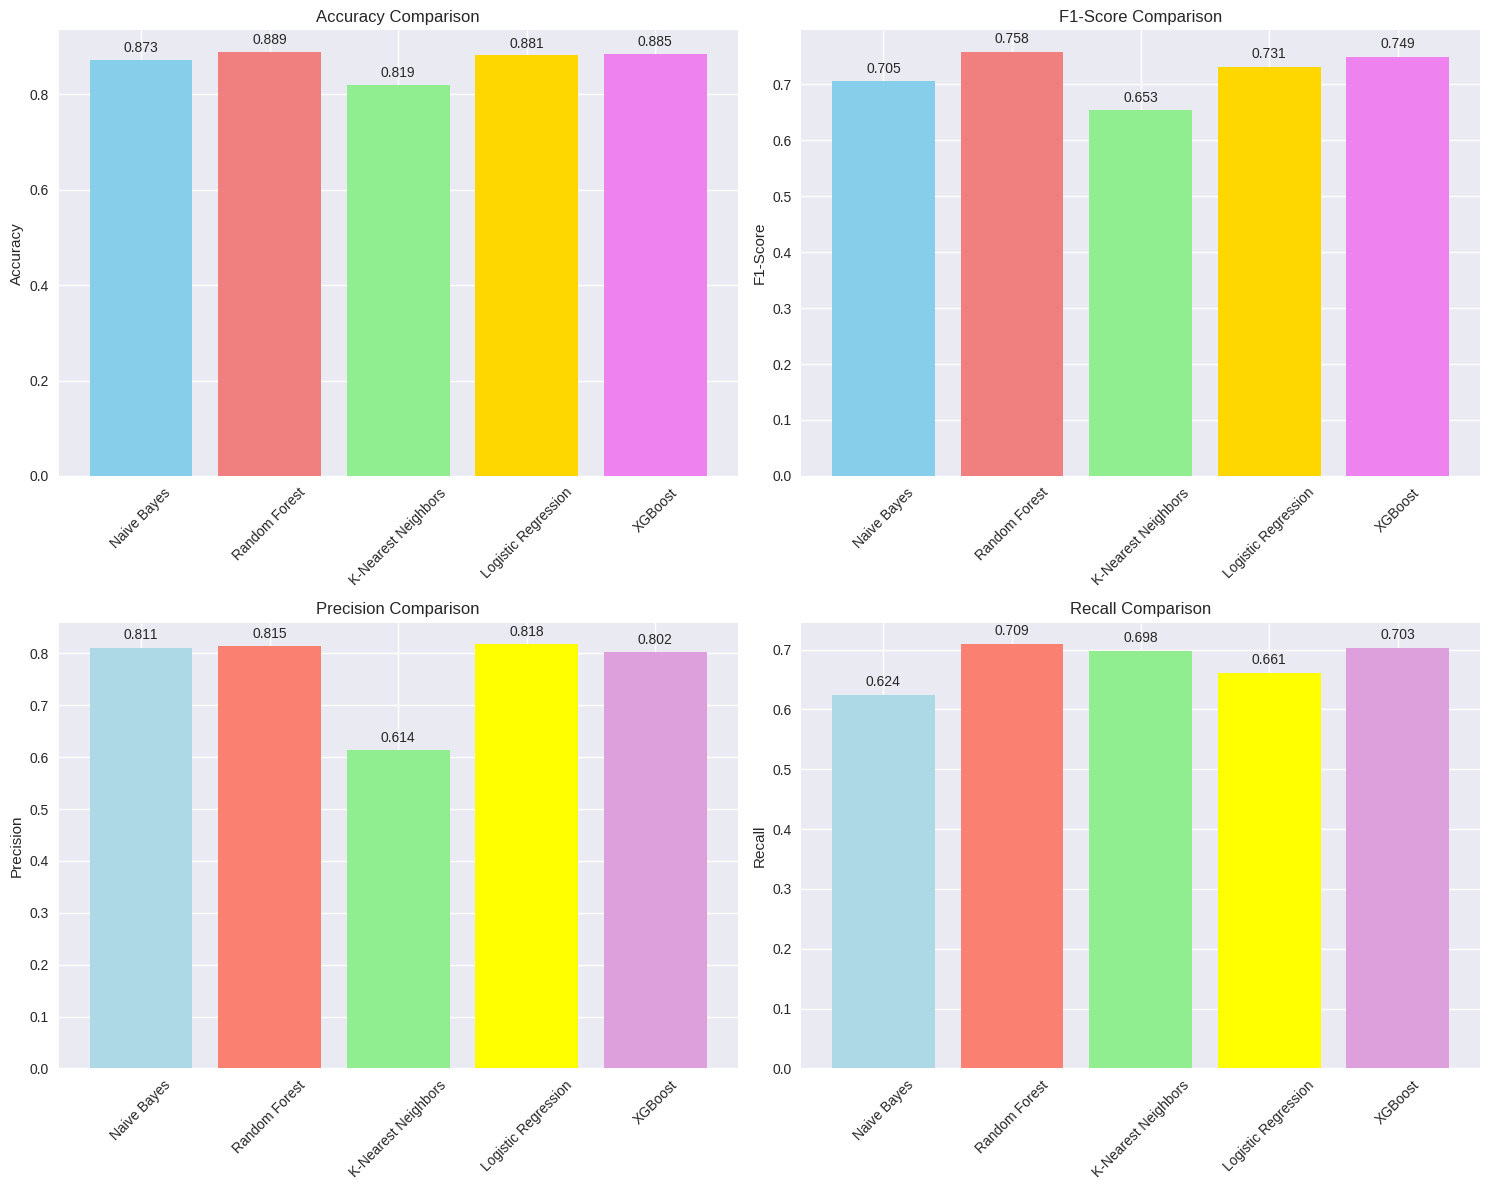

In [94]:
# ========================
# 7. VISUALIZATIONS
# ========================

# Set style
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Accuracy and F1-Score Comparison
metrics_1 = ['Accuracy', 'F1-Score']
for i, metric in enumerate(metrics_1):
    axes[0, i].bar(comparison_df['Model'], comparison_df[metric], color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'violet'])
    axes[0, i].set_title(f'{metric} Comparison')
    axes[0, i].set_ylabel(metric)
    axes[0, i].tick_params(axis='x', rotation=45)
    # Add value labels on bars
    for j, v in enumerate(comparison_df[metric]):
        axes[0, i].text(j, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 2. Precision and Recall Comparison
metrics_2 = ['Precision', 'Recall']
for i, metric in enumerate(metrics_2):
    axes[1, i].bar(comparison_df['Model'], comparison_df[metric], color=['lightblue', 'salmon', 'lightgreen', 'yellow', 'plum'])
    axes[1, i].set_title(f'{metric} Comparison')
    axes[1, i].set_ylabel(metric)
    axes[1, i].tick_params(axis='x', rotation=45)
    # Add value labels on bars
    for j, v in enumerate(comparison_df[metric]):
        axes[1, i].text(j, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('ML_Models_Performance_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

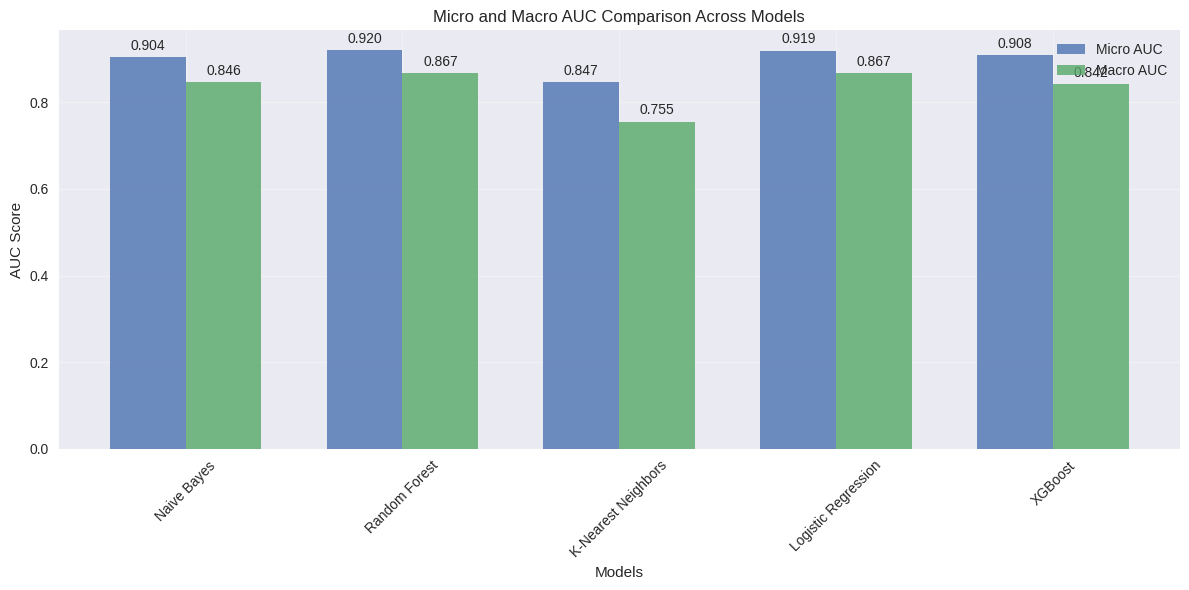

In [95]:
# AUC Comparison Plot
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(comparison_df))
width = 0.35

plt.bar(x_pos - width/2, comparison_df['Micro AUC'], width, label='Micro AUC', alpha=0.8)
plt.bar(x_pos + width/2, comparison_df['Macro AUC'], width, label='Macro AUC', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('AUC Score')
plt.title('Micro and Macro AUC Comparison Across Models')
plt.xticks(x_pos, comparison_df['Model'], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(comparison_df['Micro AUC']):
    plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
for i, v in enumerate(comparison_df['Macro AUC']):
    plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('ML_Models_AUC_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()